# <center>LlamaIndex 图文混排 PDF 检索实战</center>

# 整体认知与技术总览

&emsp;&emsp;今天我们聚焦的是 LlamaIndex 在图文混排 PDF 处理领域的系统性解决方案。在生成式 AI 重塑企业知识管理的今天,非结构化数据的处理能力决定了 RAG 系统的核心竞争力。而 PDF——这个诞生于 1993 年的"数字纸张"格式——正成为横亘在 AI 与企业知识之间最顽固的壁垒。

&emsp;&emsp;结合实战验证与技术调研,我们会重点抓住三个核心维度:
* 第一,为什么图文混排 PDF 是 RAG 的"最后一公里"难题;

* 第二,LlamaIndex 如何通过 8 步渐进式实战路径系统性地解决这些痛点;

* 第三,不同技术方案(SimpleDirectoryReader、PyMuPDF、LlamaParse、MinerU)的能力边界与选型策略。

&emsp;&emsp;为了把这些内容讲清楚,接下来我们会按"问题定位 → 技术全景 → 能力进阶"的主线展开。我们会先从企业数据现状出发,理解四大技术挑战的本质,然后通过 8 步实战技术地图建立对解决方案的整体认知,最终明确从 L0 基础到 L5 智能体的完整学习路径。

# <center>一、为何图文混排 PDF 是 RAG 的"最后一公里"?



&emsp;&emsp;在开始技术方案之前,我们需要先理解问题的本质。这一章将从企业数据现状出发,剖析图文混排 PDF 处理的四大核心挑战,以及传统方案为何在这些场景下失效。只有深刻理解了问题,才能真正掌握后续技术方案的设计思路。

### 1.1 企业数据现状:80% 的高价值信息被"锁"在 PDF 中

&emsp;&emsp;据估计,企业知识库中超过 **80%** 的高价值信息——财务报表、技术规格书、法律合同、科研论文——被锁定在 PDF 格式中。这个比例背后反映的是一个根本矛盾:PDF 的设计初衷是确保在任何设备上**视觉呈现的一致性**,而非数据的**可机器读取性**。

&emsp;&emsp;PDF 的本质是"数字纸张",内部实际上是一系列绘图指令的集合("在坐标 X,Y 处放置字符 Z"),而不是语义化的文档结构。这导致了人类视角与机器视角的巨大鸿沟:

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>人类视角 vs 机器视角的认知差异</font></p>
<div class="center">

| 维度 | 人类视角 | 机器视角 |
|------|---------|----------|
| **多栏布局** | 自动按列阅读 | 跨列串读,句子断裂 |
| **表格** | 清晰的行列结构 | 扁平的字符串流 |
| **图表** | 关键数据可视化 | 被丢弃或仅保留占位符 |
| **标题层级** | 明确的逻辑结构 | 仅凭字号区分,易误判 |


</div>
<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260109110543535.png" width=50%></div>

&emsp;&emsp;这种认知差异使得传统的文本提取方案在处理图文混排 PDF 时,最多只能发挥 **30%** 的潜力。

### 1.2 四大技术挑战:当传统 RAG 遇上复杂 PDF

&emsp;&emsp;当 RAG 系统试图"理解"图文混排的 PDF 时,面临着多维度的技术挑战。这些挑战不是孤立的,而是相互交织、层层递进的:

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>图文混排 PDF 的四大技术挑战</font></p>
<div class="center">

| 挑战 | 现象描述 | 技术根源 | 影响范围 |
|------|---------|----------|---------|
| **布局语义丢失** | 多栏论文的"第一栏第一行"直接连接"第二栏第一行",句子完全错乱 | 传统解析器按线性流提取文本 | 学术论文、技术白皮书 |
| **多模态信息割裂** | 用户问"图 3 展示了什么趋势?",系统答"文档中未提及图 3" | 纯文本提取完全忽略图像层 | 技术文档、研究报告 |
| **表格结构熵增** | 用户问"Q4 营收是多少?",系统回答错误数值 | 表格被扁平化,列数据错位 | 财务报表、数据分析 |
| **上下文碎片化** | 答案断章取义,缺乏前因后果 | 定长分块将图表标题与图表本身切断 | 所有复杂文档 |

</div>

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260109112914994.png" width=50%></div>

&emsp;&emsp;这四大挑战构成了一个递进的技术难度金字塔:布局语义丢失是基础层问题,多模态信息割裂和表格结构熵增是中间层问题,而上下文碎片化则是顶层的系统性问题。<font color=red>只有系统性地解决这些挑战,才能构建真正可用的图文混排 PDF RAG 系统</font>。

### 1.3 传统方案为何失效?

&emsp;&emsp;以最常用的 `pypdf` 库为例,传统流程是:PDF → pypdf 提取文本 → 固定分块 → 向量化 → 检索 → 生成。这个看似完整的流程,在面对真实世界的图文混排 PDF 时,存在四个致命缺陷:

&emsp;&emsp;**缺陷一:只能提取"可编辑"文本**。扫描件 PDF 完全无法处理,这意味着大量历史文档、合同、发票等关键业务数据被排除在外。

&emsp;&emsp;**缺陷二:忽略所有图像内容**。图表、流程图、架构图全部丢失,而这些视觉元素往往承载着文档中最核心的信息。

&emsp;&emsp;**缺陷三:表格被"压扁"**。二维结构变成一维字符串,行列语义消失,导致 LLM 在回答涉及表格数据的问题时产生幻觉。

&emsp;&emsp;**缺陷四:机械分块**。不理解文档结构,可能将"图 1"和"图 1 的描述文字"切断在不同的检索块中,破坏了语义的完整性。

> &emsp;**小结**:传统的"文本提取 + 向量检索"范式,在面对真实世界的图文混排 PDF 时,最多只能发挥 **30%** 的潜力。这就是为什么图文混排 PDF 被称为 RAG 的"**最后一公里**"难题。

# <center>二、LlamaIndex 解决方案:从 6 步实战看技术全景



&emsp;&emsp;在理解了问题的本质之后,我们需要建立对解决方案的整体认知。LlamaIndex 通过引入"数据代理"和"上下文增强"的理念,从根本上重构了非结构化数据的处理管线。这一章将从 6 步实战技术地图出发,展示 LlamaIndex 如何系统性地解决图文混排 PDF 的处理难题。

### 2.1 实战技术地图

&emsp;&emsp;本课程将按照**由浅入深、渐进式验证**的路径,带你走过 PDF RAG 的完整技术演进。与传统的"四阶段"划分不同,我们采用更细粒度的 6 步实战路径,每一步都对应一个明确的技术能力提升:

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>LlamaIndex 6 步实战技术地图</font></p>
<div class="center">

| 步骤 | 核心技术 | 能力层级 | 解决的痛点 | 验证重点 |
|------|---------|---------|-----------|---------|
| **步骤 1** | SimpleDirectoryReader + VectorStoreIndex | L1 入门 | 快速验证 MVP | 基础文本检索能力 |
| **步骤 2** | PyMuPDF + MultiModalVectorStoreIndex | L2 进阶 | 多模态信息割裂 | 图文联合检索 |
| **步骤 3** | LlamaParse(4 种解析模式) | L4 企业级 | 布局语义丢失 + 表格结构熵增 | Markdown 结构化输出 |
| **步骤 4** | MinerU(VLM+OCR 双模型) | L4 企业级 | 扫描件/中文识别差 | VLM+OCR 分层解析 |
| **步骤 5** | 三大方案对比实验 | 对比验证 | 选型决策困难 | 准确率、成本、速度对比 |
| **步骤 6** | ReActAgent + Tool Calling | L5 智能体 | 静态检索局限 | 多步推理与工具调用 |

</div>



<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260109110543130.png" width=70%></div>



&emsp;&emsp;这个 6 步路径的设计遵循三个核心原则:

&emsp;&emsp;**原则一:渐进式能力提升**。从 L1 基础入门到 L5 智能体,每一步都在前一步的基础上增加新的技术能力,确保学习曲线平滑。

&emsp;&emsp;**原则二:痛点驱动**。每一步都明确对应一个或多个实际痛点,避免为了技术而技术,确保学到的每个技术点都有明确的应用场景。

&emsp;&emsp;**原则三:可验证性**。每一步都有明确的验证重点和成功判据,学习者可以通过实际运行结果判断是否真正掌握了该技术。

### 2.2 技术选型对比:解析工具全景

&emsp;&emsp;在动手之前,我们需要理解不同解析工具的能力边界。LlamaIndex 的价值不在于提供单一解决方案,而在于**编排能力**——它让你可以根据文档类型灵活选择解析器,并统一接入后续的索引、检索、生成流程。

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>四大解析工具能力对比</font></p>
<div class="center">

| 工具 | 类型 | 文本提取 | 图片提取 | 表格重建 | OCR | 成本 | 适用场景 |
|------|------|---------|---------|---------|-----|------|---------|
| **pypdf** | 开源库 | ✅ 基础 | ❌ | ❌ | ❌ | 免费 | 纯文本 PDF,快速验证 |
| **PyMuPDF** | 开源库 | ✅ 较好 | ✅ | ❌ | ❌ | 免费 | 需要提取图片的场景 |
| **LlamaParse** | 云服务 | ✅ 优秀 | ✅ | ✅✅ | ✅ | ~$0.003/页 | 企业级,复杂表格 |
| **MinerU** | 云服务/本地 | ✅ 优秀 | ✅ | ✅ | ✅✅ | ~$0.01/页 | 扫描件,中文 OCR |

</div>



&emsp;&emsp;从上表可以看出,不同工具在能力、成本、部署方式上存在显著差异。<font color=red>没有"最好"的工具,只有"最合适"的工具</font>。选型建议如下:

&emsp;&emsp;**快速原型**:pypdf → 5 分钟验证概念,零成本快速上线。

&emsp;&emsp;**需要图片**:PyMuPDF → 开源免费,图片提取可靠,适合图文混排但表格简单的场景。

&emsp;&emsp;**生产级表格**:LlamaParse → 表格重建专家,Markdown 输出,适合财务报表、数据分析等场景。

&emsp;&emsp;**扫描件/中文**:MinerU → PaddleOCR 加持,中文识别极佳,支持本地部署,适合数据隐私要求高的企业。

# <center> 三、实战拆解与逐步运行讲解 </center>



&emsp;&emsp;现在我们将通过可运行的代码，逐步验证每一个技术方案的实际效果。

&emsp;&emsp;本次实战的核心价值在于：<font color=red>不仅要让代码跑通，更要理解每一步背后的技术决策、中间结果的业务含义，以及不同方案之间的性能与成本权衡</font>。我们会从最简单的 `SimpleDirectoryReader` 开始，逐步演进到企业级的 `LlamaParse`、专注扫描件的 `MinerU`，最终实现基于 `ReActAgent` 的智能体推理。

## 步骤 1：环境与依赖准备




&emsp;&emsp;在任何 RAG 项目中，环境准备都是第一步，但这不仅仅是简单的 `pip install`。我们需要理解每个依赖包的作用、版本兼容性，以及可能遇到的环境问题。<font color=red>特别注意：Jupyter Notebook 环境中不存在 `__file__` 变量，因此所有路径处理必须使用相对路径或 `os.getcwd()`</font>。



### 1.1 依赖包安装

&emsp;&emsp;首先我们需要安装 LlamaIndex 核心库及其扩展包。以下是本次实战需要的所有依赖：

In [1]:
# 安装依赖（在 Jupyter 中执行）
#!pip install llama-index-core llama-index-llms-openai llama-index-embeddings-openai
#!pip install pypdf PyMuPDF python-dotenv

&emsp;&emsp;每个包的具体作用如下：

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>依赖包作用说明</font></p>
<div class="center">

| 依赖包 | 作用 | 是否必需 | 备注 |
|-------|------|---------|------|
| `llama-index-core` | LlamaIndex 核心框架 | ✅ 必需 | 提供索引、检索、查询引擎 |
| `llama-index-llms-openai` | OpenAI LLM 集成 | ✅ 必需 | 支持 GPT-4o 等模型 |
| `llama-index-embeddings-openai` | OpenAI Embedding 集成 | ✅ 必需 | 文本向量化 |
| `pypdf` | PDF 基础解析库 | ⚠️ 可选 | `SimpleDirectoryReader` 依赖 |
| `PyMuPDF` (fitz) | 高级 PDF 操作库 | ✅ 必需 | 图片提取、多模态索引 |
| `python-dotenv` | 环境变量管理 | ✅ 必需 | 安全加载 API Key |

</div>



### 1.2 环境变量配置

&emsp;&emsp;API Key 的配置是 RAG 项目的核心安全点。我们采用 `.env` 文件 + `python-dotenv` 的标准方案，避免在代码中硬编码敏感信息。

In [3]:
import os
from dotenv import load_dotenv

# 加载环境变量（.env 文件中需要配置 OPENAI_API_KEY）
load_dotenv(override=True)

# 验证 API Key
api_key = os.getenv("OPENAI_API_KEY")
base_url = os.getenv("OPENAI_BASE_URL")
if api_key:
    print(f"✅ OPENAI_API_KEY 已配置: {api_key[:20]}...")
else:
    raise ValueError("❌ 请设置 OPENAI_API_KEY 环境变量")

✅ OPENAI_API_KEY 已配置: sk-proj-jv_WaXHuYnGt...


&emsp;&emsp;这里的 `override=True` 参数确保每次重新运行时都会重新读取 `.env` 文件，避免配置更新后需要重启 Kernel。

> &emsp;**常见问题排查**：如果提示找不到 `.env` 文件，请在 Notebook 同级目录创建该文件，并添加：
> ```
> OPENAI_API_KEY=your_key_here
> OPENAI_BASE_URL=https://api.openai.com/v1  # 可选
> ```


## 步骤 2：核心配置与参数全览



&emsp;&emsp;在 LlamaIndex 中，全局配置通过 `Settings` 对象统一管理。理解这些配置参数不仅能让代码正确运行，更重要的是能够根据业务需求进行针对性优化。<font color=red>这一步看似简单，但实际上决定了整个 RAG 系统的成本、速度、准确性三大核心指标</font>。

### 2.1 LLM 配置（大语言模型）

&emsp;&emsp;LLM 是 RAG 系统的"大脑"，负责理解查询意图、生成最终答案。我们这里使用 OpenAI 的 `gpt-4o` 模型，它在多模态理解和推理能力上表现优秀。

In [4]:
from llama_index.core import Settings
from llama_index.llms.openai import OpenAI
from llama_index.embeddings.openai import OpenAIEmbedding

# 配置 LLM（大语言模型）
Settings.llm = OpenAI(
    model="gpt-4o",           # 使用 GPT-4o 模型
    temperature=0,             # 降低随机性，输出更稳定
    api_key=api_key,
    api_base=base_url          # 可选：使用代理 API
)

# 配置 Embedding 模型（用于向量化）
Settings.embed_model = OpenAIEmbedding(
    model="text-embedding-3-small",  # OpenAI 最新嵌入模型
    api_key=api_key,
    api_base=base_url
)

/opt/anaconda3/envs/mineru/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 2.2 关键参数解析与成本优化



&emsp;&emsp;这些参数对系统的影响和优化建议如下：

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>LLM 与 Embedding 配置参数对比</font></p>
<div class="center">

| 配置项 | 默认值 | 推荐值 | 作用说明 | 成本影响 |
|-------|-------|-------|---------|---------|
| `model` (LLM) | gpt-3.5-turbo | gpt-4o | 模型能力决定答案质量 | gpt-4o: $5/1M tokens |
| `temperature` | 0.7 | 0 | 控制输出随机性（0=确定性） | 无直接影响 |
| `model` (Embedding) | text-embedding-ada-002 | text-embedding-3-small | 向量化质量影响检索准确率 | $0.02/1M tokens |
| `chunk_size` | 1024 | 512-2048 | 文本分块大小 | 影响检索粒度与成本 |

</div>





&emsp;&emsp;从上表可以看到，**Embedding 成本远低于 LLM 成本**（约为 1/100）。因此在实际项目中，我们应该：
- 优先优化 LLM 调用次数（如减少无效查询、缓存结果）

- Embedding 可以使用更高维度的模型（如 `text-embedding-3-large`）以提升检索准确率

- `temperature=0` 确保在相同查询下输出稳定，便于调试和 A/B 测试

## 步骤 3：最小可行 RAG（L1 入门）

#### 3.1 文档加载与初步分析



&emsp;&emsp;`SimpleDirectoryReader` 是 LlamaIndex 提供的通用文档加载器，它能自动识别 PDF、DOCX、TXT 等常见格式，并调用对应的解析器提取文本内容。对于 PDF 文件，它默认使用 `pypdf` 库进行解析。

In [10]:
from pathlib import Path
from llama_index.core import SimpleDirectoryReader

# 指定文档目录
doc_dir = Path("./data")

if not doc_dir.exists():
    raise FileNotFoundError(f"❌ 文档目录不存在: {doc_dir}")

# 创建文档读取器
reader = SimpleDirectoryReader(
    input_dir=str(doc_dir),    # 目标文件夹
    recursive=True,             # 递归读取子目录
    required_exts=[".pdf"]      # 仅处理 PDF 文件
)

# 加载文档
documents = reader.load_data()

print(f"✅ 成功加载 {len(documents)} 个文档片段")

# 查看第一个文档的结构
if documents:
    doc = documents[0]
    print(f"\n📄 示例文档结构:")
    print(f"   - 文本长度: {len(doc.text)} 字符")
    print(f"   - 元数据: {doc.metadata}")

✅ 成功加载 8 个文档片段

📄 示例文档结构:
   - 文本长度: 1012 字符
   - 元数据: {'page_label': '1', 'file_name': '测试文档&图片.pdf', 'file_path': '/Users/mac/PycharmProjects/JupyterProject/RAGProject/7_pdf_data_rag/data/测试文档&图片.pdf', 'file_type': 'application/pdf', 'file_size': 9301908, 'creation_date': '2026-01-03', 'last_modified_date': '2026-01-03'}


### 3.2 中间结果分析：Document 对象的结构



&emsp;&emsp;`Document` 对象的内部结构对于后续的索引构建至关重要：

- **`text` 字段**：存储从 PDF 提取的原始文本内容。`pypdf` 会按照 PDF 的逻辑顺序提取文本，但<font color=red>无法理解多栏布局</font>，可能出现跨列读取的问题。

- **`metadata` 字段**：包含文件路径、文件名等元信息，这些信息会被传递到后续的检索结果中，便于溯源。

- **分页策略**：`SimpleDirectoryReader` 默认将整个 PDF 文件作为一个 Document，而不是按页拆分。这意味着如果 PDF 有 50 页，`documents[0].text` 会包含所有 50 页的文本。

&emsp;&emsp;这种"全文档加载"的策略在简单场景下没有问题，但在复杂图文混排 PDF 中会带来两个问题：

1. 单个 Document 过大，后续分块时可能切断语义

2. 图片信息完全丢失，无法回答"图中展示了什么"的问题



### 3.3 索引构建与向量化

&emsp;&emsp;接下来我们要将文档转换为可检索的向量索引。`VectorStoreIndex` 会自动完成三个关键步骤：

In [12]:
from llama_index.core import VectorStoreIndex

# 从文档构建向量索引
index = VectorStoreIndex.from_documents(
    documents,
    show_progress=True  # 显示进度条
)

print("✅ 向量索引构建完成")

Generating embeddings: 100%|██████████| 8/8 [00:02<00:00,  2.87it/s]

✅ 向量索引构建完成


在这个过程中，LlamaIndex 自动执行了以下操作：

1. **文档切分（Chunking）**：将长文本按 `chunk_size`（默认 1024 tokens）切分为多个小块（Node）

2. **向量化（Embedding）**：调用我们在步骤 2 中配置的 `OpenAIEmbedding` 模型，将每个文本块转换为向量

3. **存储（Storage）**：将向量和原始文本存储到内存向量库（默认使用 SimpleVectorStore）

&emsp;&emsp;通过以下代码可以查看索引的内部结构：

In [13]:
# 查看索引元数据
print(f"\n🔍 索引内部结构:")
print(f"   - 节点数量: {len(index.docstore.docs)} 个")
print(f"   - 向量维度: {index._embed_model.embed_batch_size}")

# 查看第一个节点的结构
first_node_id = list(index.docstore.docs.keys())[0]
first_node = index.docstore.docs[first_node_id]
print(f"\n📦 示例节点 (Node) 结构:")
print(f"   - 文本长度: {len(first_node.text)} 字符")
print(f"   - Node ID: {first_node.node_id}")
print(f"   - 元数据: {first_node.metadata}")


🔍 索引内部结构:
   - 节点数量: 8 个
   - 向量维度: 100

📦 示例节点 (Node) 结构:
   - 文本长度: 1012 字符
   - Node ID: 22180f2f-2a35-4790-b9c0-c87adf6326ba
   - 元数据: {'page_label': '1', 'file_name': '测试文档.pdf', 'file_path': '/Users/mac/大模型资料/多模态RAG/七大场景llama-Index进阶实战/测试文档&图片/测试文档.pdf', 'file_type': 'application/pdf', 'file_size': 9294271, 'creation_date': '2026-01-05', 'last_modified_date': '2026-01-05'}


#### 3.4 执行查询与结果分析

&emsp;&emsp;将索引转换为查询引擎（QueryEngine），执行实际的问答任务：

In [7]:
# 将索引转换为查询引擎
query_engine = index.as_query_engine(
    similarity_top_k=3  # 每次检索最相关的 3 个文档块
)

# 执行查询
question = "这篇文档主要讨论了哪些核心议题？"
print(f"\n❓ 问题: {question}")

response = query_engine.query(question)
print(f"\n💡 回答:\n{response}")

# 查看检索到的源文档
print("\n📚 检索到的源文档:")
for i, node in enumerate(response.source_nodes):
    print(f"\n--- 文档 {i+1} (相似度: {node.score:.4f}) ---")
    print(f"内容预览: {node.text[:200]}...")


❓ 问题: 这篇文档主要讨论了哪些核心议题？


2026-01-07 15:34:46,786 - INFO - HTTP Request: POST https://ai.devtool.tech/proxy/v1/embeddings "HTTP/1.1 200 OK"
2026-01-07 15:34:50,230 - INFO - HTTP Request: POST https://ai.devtool.tech/proxy/v1/chat/completions "HTTP/1.1 200 OK"



💡 回答:
这篇文档主要讨论了几个核心议题，包括：LangChain作为开源项目的底层开发框架的应用及其争议，特别是在GPT-3.5和GPT-4模型发布后，LangChain的复杂性和冗余性引发的开发者流失问题。此外，文档还介绍了LangChain在经历改革后的新功能和模块划分，以及LangGraph作为LangChain的高层次封装在Multi-Agent系统中的应用。

📚 检索到的源文档:

--- 文档 1 (相似度: 0.3051) ---
内容预览: 同时 LangChain 也是很多著名的开源项目的底层开发框架，如字节前端时间开源的 Deep Research
应用 deerflow 就是采用了 LangChain&LangGraph 框架：
项目主页：https://github.com/bytedance/deer-flow
此外如谷歌近期开源的 Gemini Fullstack LangGraph Quickstart 热门项目，也是使...

--- 文档 2 (相似度: 0.2881) ---
内容预览: 但是，伴随着 GPT-3.5 模型的发布，对话模型正式登上历史的舞台，并逐渐成为主流。而得益于对话
模型更强的指令跟随能力，很多 GPT-3 需要借助 LangChain 才能完成的工作，已经成为 GPT-3.5 原生自带
的一些功能。而等到 GPT-4 逐渐普及，包括调用外部工具（ Function calling ）、结构化输出、系统提示
词等功能，都成了模型的基础功能。而对于开发者而言，此时...

--- 文档 3 (相似度: 0.2719) ---
内容预览: 而这也使得在某个时间段， LangChain 的开发者大规模流失。
举个例子，为了更好的兼容不同模型的调用，谷歌 ADK 采用了 LiteLlm 作为底层模型调度框架，一
个库即可调用各类模型，而 LangChain 则为每个主流模型单独封装了一个库，调用不同模型的时候
需要导入不同模型对应的库，例如调用 DeepSeek 就需要安装langchain-deepseek，而调用
Gemini 则需...


### 3.5 SimpleDirectoryReader vs PyMuPDF 性能对比



&emsp;&emsp;在进入下一步之前，需要理解 `SimpleDirectoryReader`（基于 `pypdf`）的局限性。让我们通过对比表格来看看它与更强大的 `PyMuPDF` 的差异：

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>SimpleDirectoryReader vs PyMuPDF 对比</font></p>
<div class="center">

| 对比维度 | SimpleDirectoryReader (pypdf) | PyMuPDF (fitz) |
|---------|------------------------------|----------------|
| **文本提取速度** | 中等 | ⚡ 极快（业界最快） |
| **图片提取能力** | ❌ 不支持 | ✅ 完美提取（像素级） |
| **表格识别** | ❌ 压扁为文本 | ❌ 同样弱 |
| **多栏布局处理** | ❌ 跨列读取 | ❌ 无语义理解 |
| **代码复杂度** | ⭐ 极简（2行代码） | ⭐⭐ 简单（需手动处理） |
| **适用场景** | MVP 快速验证 | 需要图片的多模态场景 |

</div>

&emsp;&emsp;从上表可以看出，`SimpleDirectoryReader` 的优势在于<font color=red>极简的使用方式</font>，但在处理图文混排 PDF 时，它只能提取文本，图片信息会完全丢失。因此在步骤 4 中，我们将引入 `PyMuPDF` 来解决多模态信息割裂的问题。


## 步骤 4：多模态索引与检索（L2 进阶）


&emsp;&emsp;在步骤 3 中，我们验证了基础的文本检索能力，但遇到了一个关键问题：<font color=red>系统无法回答"图中展示了什么"这类问题</font>。这是因为 `SimpleDirectoryReader` 只提取了文本，图片信息被直接丢弃。现在我们要让系统具备"看图"的能力，实现真正的多模态检索。

### 4.1 为什么需要多模态索引？

&emsp;&emsp;在实际的 PDF 文档中，大量关键信息是通过图表、流程图、架构图等视觉元素传递的。例如：
- 技术文档中的系统架构图

- 学术论文中的实验数据图

- 合同文件中的签名和印章

- 财务报表中的趋势图


&emsp;&emsp;如果只依赖文本检索，LLM 无法理解这些视觉信息，导致答案不完整甚至错误。`MultiModalVectorStoreIndex` 通过以下方式解决这个问题：

1. 使用 `PyMuPDF` 提取 PDF 中的所有图片

2. 将图片和文本分别向量化

3. 在检索时同时匹配文本和图片

4. 使用支持视觉输入的多模态 LLM（如 GPT-4o）生成答案



### 4.2 安装多模态依赖

&emsp;&emsp;首先我们需要安装额外的依赖包：

In [11]:
# 安装多模态依赖
#!pip install llama-index-multi-modal-llms-openai PyMuPDF pillow llama-index-embeddings-clip git+https://github.com/openai/CLIP.git

&emsp;&emsp;其中：
- `llama-index-multi-modal-llms-openai`：提供 GPT-4o 的多模态接口

- `PyMuPDF`：用于精确提取 PDF 中的图片

- `pillow`：图片处理库，用于图片格式转换

- `llama-index-embeddings-clip`：LlamaIndex 提供的 CLIP 向量化接口封装，用于生成文本和图像的多模态向量

- `git+https://github.com/openai/CLIP.git`：OpenAI 官方 CLIP 模型的核心实现库，提供模型架构与权重加载，是上述接口的底层依赖



### 4.3 使用 PyMuPDF 提取图片

&emsp;&emsp;`PyMuPDF`（导入名为 `fitz`）提供了强大的图片提取能力。我们先定义一个辅助函数来提取指定页面的所有图片：

In [12]:
import os
import fitz  # PyMuPDF
from pathlib import Path

def extract_images_from_pdf_page(doc, page_index: int, output_dir: str) -> list:
    """
    从 PDF 的指定页面提取所有图片并保存到磁盘

    Args:
        doc: PyMuPDF Document 对象
        page_index: 页面索引（从 0 开始）
        output_dir: 图片保存目录

    Returns:
        list: 保存的图片路径列表
    """
    # 获取指定页面
    page = doc[page_index]

    # 获取页面中的所有图片列表
    image_list = page.get_images(full=True)
    saved_images = []

    for image_index, img in enumerate(image_list):
        # xref 是图片的引用 ID
        xref = img[0]
        
        # 提取图片二进制数据和扩展名
        base_image = doc.extract_image(xref)
        image_bytes = base_image["image"]
        image_ext = base_image["ext"]

        # 生成唯一的图片文件名
        image_filename = f"page_{page_index+1}_img_{image_index+1}.{image_ext}"
        image_path = os.path.join(output_dir, image_filename)

        # 将图片数据保存到本地
        with open(image_path, "wb") as img_file:
            img_file.write(image_bytes)

        saved_images.append(image_path)

    return saved_images

&emsp;&emsp;使用这个函数提取 PDF 中的所有图片：

In [14]:
# 使用 PyMuPDF 提取 PDF 中的图片
pdf_path = "./data/测试文档.pdf"
output_dir = "./extracted_images"

# 检查 PDF 文件是否存在
if Path(pdf_path).exists():

    # 创建图片输出目录
    os.makedirs(output_dir, exist_ok=True)
    print(f"\n📷 正在从 PDF 提取图片...")

    # 打开 PDF 文档
    doc = fitz.open(pdf_path)
    all_image_paths = []
    
    # 遍历文档的每一页
    for i in range(len(doc)):
        
        # 提取当前页面的所有图片并返回保存路径
        paths = extract_images_from_pdf_page(doc, i, output_dir)
        all_image_paths.extend(paths)
    
    # 关闭文档释放资源
    doc.close()

    print(f"✅ 共提取 {len(all_image_paths)} 张图片")
    print(f"📂 图片保存路径: {output_dir}")
else:
    print(f"⚠️ PDF 文件不存在: {pdf_path}")
    all_image_paths = []


📷 正在从 PDF 提取图片...
✅ 共提取 15 张图片
📂 图片保存路径: ./extracted_images


### 4.4 中间结果分析：图片提取的内部机制



&emsp;&emsp;深入理解 PyMuPDF 的图片提取原理：

1. **`get_images(full=True)`**：返回页面中所有图片的引用列表(ID列表)。`full=True` 表示包含完整的图片信息（包括尺寸、颜色空间等）

2. **`xref`（交叉引用）**：PDF 内部使用 xref 来标识对象。每个图片都有一个唯一的 xref，我们通过它来提取实际的图片数据

3. **`extract_image(xref)`**：根据 xref 提取图片的二进制数据、格式（PNG/JPEG）等信息

4. **像素级完美提取**：PyMuPDF 提取的是 PDF 中嵌入的原始图片，不是渲染后的截图，因此质量无损

&emsp;&emsp;执行后，你会在 `extracted_images` 目录下看到提取的所有图片，文件名格式为 `page_1_img_1.png`，方便追溯图片来源。


### 4.5 构建多模态索引



&emsp;&emsp;将提取的图片和原始文本一起构建多模态索引：
这里必须提前安装依赖：

* git+https://github.com/openai/CLIP.git`

* llama-index-embeddings-clip

In [15]:
from llama_index.multi_modal_llms.openai import OpenAIMultiModal
from llama_index.core.indices import MultiModalVectorStoreIndex
from llama_index.core import SimpleDirectoryReader

# 1. 配置多模态 LLM (GPT-4o)
openai_mm_llm = OpenAIMultiModal(
    model="gpt-4o",
    api_key=api_key,
    api_base=base_url,
    max_new_tokens=500
)

# 2. 加载数据：整合提取出的图片与原始文本
if all_image_paths:
    # 从指定输出目录加载所有提取到的图片文档
    image_reader = SimpleDirectoryReader(input_dir=output_dir)
    image_docs = image_reader.load_data()
    print(f"✅ 加载 {len(image_docs)} 个图片文档")
else:
    # 如果没有图片路径，则初始化为空列表以便后续合并
    image_docs = []

# 从原始 PDF 文件中加载文本内容
text_reader = SimpleDirectoryReader(input_files=[pdf_path])
text_docs = text_reader.load_data()

# 将文本和图片文档合并为统一的列表，作为多模态索引的数据源
all_docs = text_docs + image_docs

# 3. 构建多模态索引
print(f"\n🔧 正在构建多模态索引...")
mm_index = MultiModalVectorStoreIndex.from_documents(
    all_docs
)
print("✅ 多模态索引构建完成")

/var/folders/fl/8wq5_lz53ln9ypplts4z_1tr0000gn/T/ipykernel_89861/2362688605.py:6: DeprecationWarning: Call to deprecated class OpenAIMultiModal. (The package has been deprecated and will no longer be maintained. Please use llama-index-llms-openai (preferably the Responses API) instead. See Multi Modal LLMs documentation for a complete guide on migration: https://docs.llamaindex.ai/en/stable/understanding/using_llms/using_llms/#multi-modal-llms) -- Deprecated since version 0.5.2.
  openai_mm_llm = OpenAIMultiModal(


✅ 加载 15 个图片文档

🔧 正在构建多模态索引...


2026-01-09 14:39:26,095 - INFO - HTTP Request: POST https://ai.devtool.tech/proxy/v1/embeddings "HTTP/1.1 200 OK"


✅ 多模态索引构建完成


### 4.6 MultiModalVectorStoreIndex 内部结构解析


&emsp;&emsp;多模态索引的工作机制是本步骤最核心的技术点：

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260109110537185.png" width=50%></div>



&emsp;&emsp;**关键设计**：

1. **双向量库架构**：

   - 文本向量：使用 `OpenAIEmbedding` (text-embedding-3-small)

   - 图片向量：使用 CLIP 模型（将图片转换为与文本同一向量空间）

2. **统一检索接口**：

   - 用户查询被同时转换为**文本向量**和**多模态向量**

   - 在文本库和图片库中分别进行相似度搜索

   - 合并结果并按相似度排序

3. **节点类型区分**：

   - `TextNode`：包含文本内容 + 元数据
   
   - `ImageNode`：包含图片路径 + 图片嵌入向量

&emsp;&emsp;我们可以通过以下代码验证索引中的节点类型分布：

In [21]:
from llama_index.core.schema import ImageNode, TextNode

# 统计节点类型
text_nodes = [n for n in mm_index.docstore.docs.values() if isinstance(n, TextNode)]
image_nodes = [n for n in mm_index.docstore.docs.values() if isinstance(n, ImageNode)]

print(f"\n📊 索引节点统计:")
print(f"   - 文本节点: {len(text_nodes)} 个")
print(f"   - 图片节点: {len(image_nodes)} 个")
print(f"   - 总节点数: {len(mm_index.docstore.docs)} 个")


📊 索引节点统计:
   - 文本节点: 23 个
   - 图片节点: 15 个
   - 总节点数: 23 个


### 4.7 执行多模态查询

&emsp;&emsp;执行包含图片内容的查询。<font color=red>注意：由于 CLIP 模型的限制，检索查询不能超过 77 个 tokens，因此我们需要使用简短的查询进行检索，然后用完整问题进行答案生成</font>。展示了所谓 "Small-to-Big" (小搜大问) 或者 检索与生成解耦 的高级用法。



* 如图所示报错：
<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260109110543122.png" width=80%></div>

In [ ]:
from llama_index.core import QueryBundle

# 1. 构造简短 Query 用于检索（避开 77 token 限制）
retrieval_query = "LangChain architecture diagram Data Connection Agents"
retrieval_bundle = QueryBundle(query_str=retrieval_query)

# 2. 检索相关节点
retriever = mm_index.as_retriever(similarity_top_k=3)
retrieved_nodes = retriever.retrieve(retrieval_bundle)

# 3. 使用完整问题进行问答
full_question = """文档第一页文本中提到"LangChain 像搭乐高积木一样组合组件"，请结合该页的架构图解释：位于 "Data Connection" 和 "Agents" 之间的核心模块是什么，它在乐高组合中起到了什么链接作用？请使用中文回答"""

print(f"\n❓ 完整问题: {full_question}")

# 4. 创建查询引擎并生成答案
engine = mm_index.as_query_engine(
    image_llm=openai_mm_llm,
    similarity_top_k=3
)

# 将完整问题封装为 QueryBundle 对象
full_query_bundle = QueryBundle(query_str=full_question)

# 4. 创建引擎并合成回答
# 注意：我们需要先创建一个"空"的 engine，然后手动调用 synthesize
result = engine.synthesize(
    full_query_bundle, 
    nodes=retrieved_nodes
)

print(f"\n💡 回答:\n{result}")

# 展示检索到的图片引用
print("\n📚 检索到的源节点:")
for i, node in enumerate(retrieved_nodes):
    node_type = type(node.node).__name__
    print(f"  [{i+1}] 类型: {node_type}, 相似度: {node.score:.4f}")
    
    if isinstance(node.node, ImageNode):
        file_path = node.node.metadata.get('file_path', '未知')
        print(f"      📷 引用图片: {file_path}")
    else:
        print(f"      📄 文本预览: {node.node.text[:100]}...")

2026-01-07 15:46:30,262 - INFO - HTTP Request: POST https://ai.devtool.tech/proxy/v1/embeddings "HTTP/1.1 200 OK"
2026-01-07 15:46:30,303 - WARNING - Warning: openai_llm does not appear to be a multi-modal LLM. This may not work as expected.



❓ 完整问题: 文档第一页文本中提到"LangChain 像搭乐高积木一样组合组件"，请结合该页的架构图解释：位于 "Data Connection" 和 "Agents" 之间的核心模块是什么，它在乐高组合中起到了什么链接作用？请使用中文回答


2026-01-07 15:46:36,578 - INFO - HTTP Request: POST https://ai.devtool.tech/proxy/v1/chat/completions "HTTP/1.1 200 OK"



💡 回答:
根据文档第一页的架构图，位于 "Data Connection" 和 "Agents" 之间的核心模块是 "LangChain"。在乐高组合中，LangChain 起到了连接和协调的作用。它通过封装模型接口、管理内存、接入工具、构建智能体架构等功能，将数据连接与智能体的功能模块化，使得开发者可以像搭乐高积木一样灵活地组合和使用不同的组件，从而实现复杂的应用开发。

📚 检索到的源节点:
  [1] 类型: TextNode, 相似度: 0.5057
      📄 文本预览: 而这也使得在某个时间段， LangChain 的开发者大规模流失。
举个例子，为了更好的兼容不同模型的调用，谷歌 ADK 采用了 LiteLlm 作为底层模型调度框架，一
个库即可调用各类模型，而 L...
  [2] 类型: TextNode, 相似度: 0.4862
      📄 文本预览: 项目官网：https://github.com/langchain-ai/langgraph
需要注意的是， LangGraph 底层功能仍然是基于 LangChain 来实现，简单理解 LangGr...
  [3] 类型: TextNode, 相似度: 0.4392
      📄 文本预览: 此外，作为底层框架本身， LangChain 本身仍保持了非常快速的迭代速度，例如就在 5 月 29 号，
LangChain 发布最新版本，新增了目前通用智能体项目非常需要的沙盒环境（ SandBo...
  [4] 类型: ImageNode, 相似度: 0.3107
      📷 引用图片: /Users/mac/大模型资料/多模态RAG/七大场景llama-Index进阶实战/extracted_images/page_6_img_1.png
  [5] 类型: ImageNode, 相似度: 0.2655
      📷 引用图片: /Users/mac/大模型资料/多模态RAG/七大场景llama-Index进阶实战/extracted_images/page_4_img_1.png


&emsp;&emsp;查询过程解析：整体是分开两次查询的

&emsp;&emsp;当你在代码里执行 retriever.retrieve(query_str) 时，LlamaIndex 实际上在后台干了两件事：

* 动作 1：把 query_str 扔给 OpenAI 模型，拿到 Vec_A (1536维)，然后去搜文本库。

* 动作 2：把同一个 query_str 扔给 CLIP 模型，拿到 Vec_B (512维)，然后去搜图片库。

最后，它就像一个汇总员，把两边搜回来的结果（比如 3 段文字 + 2 张图片）放在一个篮子里返回给你。所以这两条线从头到尾都不需要“见面”，直到最后汇总结果。

&emsp;&emsp;总结
您把它想象成一个**“双语翻译官”**就对了：

* 对着 OpenAI 说“英语”（1536维）去找英文书（文本库）。

* 对着 CLIP 说“法语”（512维）去找法文画册（图片库）。
两本字典各查各的，互不影响。

### 4.8 图文检索结果对比分析



&emsp;&emsp;执行后你会发现，`source_nodes` 中不仅包含文本节点，还包含图片节点。GPT-4o 会"看"这些图片并结合文本生成答案。让我们对比一下有无图片时的答案质量：

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>纯文本检索 vs 图文联合检索效果对比</font></p>
<div class="center">

| 对比维度 | 纯文本检索（步骤 3） | 图文联合检索（步骤 4） |
|---------|-------------------|---------------------|
| **回答准确性** | ⚠️ 可能遗漏图中信息 | ✅ 结合视觉信息，更完整 |
| **可解释性** | 仅文本溯源 | 可展示相关图片 |
| **适用问题类型** | "文档说了什么" | "图中展示了什么" |
| **成本** | 低（仅文本 Embedding） | 中（+ CLIP Embedding） |
| **检索速度** | 快 | 中等（需处理图片向量） |

</div>




&emsp;&emsp;通过这个对比可以看出，多模态检索在处理图文混排文档时具有明显优势，但也带来了一定的成本和复杂度。在实际项目中，我们可以根据文档特点选择性使用：

- **简单文档**：优先使用步骤 3 的纯文本检索

- **图文混排文档**：使用步骤 4 的多模态检索

- **混合策略**：先用文本检索判断是否需要图片，再决定是否启用多模态

&emsp;&emsp;至此，我们已经解决了"多模态信息割裂"的问题。但还有两个核心痛点尚未解决：表格结构熵增和布局语义丢失。在步骤 5 中，我们将引入企业级的 `LlamaParse` 来解决这些问题。

## 步骤 5：企业级 LlamaParse 解析（L4 企业级）



&emsp;&emsp;在前面的步骤中，我们已经解决了多模态信息割裂的问题，但还有两个核心痛点尚未解决：<font color=red>表格结构熵增</font>和<font color=red>布局语义丢失</font>。当 PDF 中包含复杂的多行表头、嵌套表格，或者采用多栏排版时，`PyMuPDF` 和 `pypdf` 都会将表格"压扁"成无法理解的字符串流，导致 LLM 在回答涉及表格数据的问题时产生幻觉。


### 5.1 为什么需要 LlamaParse？成本与效果权衡



&emsp;&emsp;在做出技术选型之前，我们需要理解 LlamaParse 的定位：它是 LlamaIndex 官方提供的**企业级 AI 原生文档解析 SaaS**，专门针对复杂表格和结构化文档优化。让我们先看看它与前面方案的成本对比：

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>PyMuPDF vs LlamaParse 成本与效果对比</font></p>
<div class="center">

| 对比维度 | PyMuPDF | LlamaParse |
|---------|---------|-----------|
| **成本模式** | 免费开源 | 按页付费（$0.003-$0.135/页） |
| **表格识别能力** | ❌ 压扁为文本 | ✅✅ 专用 AI 模型重建 |
| **Markdown 输出** | ❌ 纯文本 | ✅ 保留 # ## ### 层级 |
| **多栏布局处理** | ❌ 跨列读取 | ✅ VLM 理解布局 |
| **部署方式** | 本地库 | 云端 API（零部署成本） |
| **处理速度** | ⚡ 极快（本地） | 🐢 慢（3-10s/页） |
| **数据隐私** | ✅ 本地可控 | ⚠️ 上传云端 |
| **适用场景** | 简单文档快速提取 | 财报、合同、学术论文 |

</div>


&emsp;&emsp;从上表可以看出，LlamaParse 的核心优势在于**表格重建能力**和**零部署成本**，但代价是**按页付费**和**必须联网**。因此在实际项目中，推荐的使用策略是：

1. **成本优先**：先用 PyMuPDF 快速判断文档是否包含复杂表格，仅对表格文档使用 LlamaParse

2. **效果优先**：所有结构化文档（财报、合同、论文）直接使用 LlamaParse

3. **混合策略**：简单文档用 PyMuPDF，复杂文档用 LlamaParse

> &emsp;**获取 API Key**：访问 https://cloud.llamaindex.ai/ 注册账号，在 API Keys 页面生成密钥。免费层提供 1000 页/天的额度。

### 5.2 LlamaParse 的四种解析模式



&emsp;&emsp;LlamaParse 提供了 4 种解析模式，它们在成本、速度、准确性上有不同的权衡：

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>LlamaParse 解析模式对比</font></p>
<div class="center">

| 模式 | 成本（每页） | 速度 | 表格识别准确率 | 适用场景 |
|-----|-----------|-----|--------------|---------|
| **Fast** | $0.003 (1 credit) | ⚡ 快 | ⭐⭐⭐ 中等 | 简单表格 |
| **Cost Effective** | $0.009 (3 credits) | 🚗 中速 | ⭐⭐⭐⭐ 较高 | 一般业务文档 |
| **Agentic** | $0.03 (10 credits) | 🐢 慢 | ⭐⭐⭐⭐⭐ 最高 | 复杂嵌套表格 |
| **Agentic Plus** | $0.135 (45 credits) | 🐌 很慢 | ⭐⭐⭐⭐⭐ 最高 | 极端复杂文档 |

</div>

&emsp;&emsp;在本次实战中，我们使用 `tier="cost_effective"`（对应 Cost Effective 模式），在成本和效果之间取得平衡。



### 5.3 安装与配置

&emsp;&emsp;首先安装 LlamaParse 依赖：

In [17]:
# 安装 LlamaParse 依赖
#!pip install llama-parse nest_asyncio

&emsp;&emsp;LlamaParse 内部使用异步 IO 进行云端通信，而 Jupyter Notebook 的事件循环与之冲突，因此需要 `nest_asyncio` 来解决这个问题：

In [1]:
!pip list | grep llama-parse

llama-index-readers-llama-parse          0.5.1
llama-parse                              0.6.88


### cost_effective 模式解析

In [13]:
import nest_asyncio
nest_asyncio.apply()  # 允许嵌套事件循环

from llama_parse import LlamaParse
from dotenv import load_dotenv
import os
load_dotenv(override=True)

# 获取 LlamaCloud API Key
llama_cloud_key = os.getenv("LLAMA_CLOUD_API_KEY")

if llama_cloud_key:
    # 配置解析器（高级参数）
    parser = LlamaParse(
        api_key=llama_cloud_key,
        result_type="markdown",    # Markdown 最适合 LLM 阅读
        verbose=True,              # 显示解析进度
        language="ch_sim",         # 优化中文 OCR 精度
        tier="cost_effective",         # 启用
        split_by_page=False        # 获得连续的 Markdown 文档
    )
    
    print("LlamaParse 配置成功（Markdown 模式）")
else:
    print("需要配置 LLAMA_CLOUD_API_KEY 环境变量")
    parser = None

LlamaParse 配置成功（Markdown 模式）


#### 5.4 执行解析

&emsp;&emsp;LlamaParse 通过 `file_extractor` 参数与 `SimpleDirectoryReader` 集成，实现对 PDF 文件的自动解析：

In [ ]:
from pathlib import Path
from llama_index.core import SimpleDirectoryReader

if parser:
    # 使用 LlamaParse 解析 PDF
    file_extractor = {".pdf": parser}
    
    print(f"\n📄 正在解析: {Path(pdf_path).name}")
    
    # 使用 SimpleDirectoryReader 加载文件并应用自定义解析器
    llama_documents = SimpleDirectoryReader(
        input_files=[pdf_path],       # PDF 文件路径
        file_extractor=file_extractor # 自定义解析器
    ).load_data()
    
    print(f"✅ 解析完成，共 {len(llama_documents)} 个文档块")
    
    # 查看 Markdown 输出
    if llama_documents:
        print(f"\n📝 Markdown 输出预览:")
        print("-" * 60)
        print(llama_documents[0].text[:2000])
        print("-" * 60)


📄 正在解析: 测试文档.pdf


2026-01-08 18:46:06,806 - INFO - HTTP Request: POST https://api.cloud.llamaindex.ai/api/parsing/upload "HTTP/1.1 200 OK"


Started parsing the file under job_id 83237e56-a6df-41e5-9a3a-da32d31d1b98


2026-01-08 18:46:08,186 - INFO - HTTP Request: GET https://api.cloud.llamaindex.ai/api/parsing/job/83237e56-a6df-41e5-9a3a-da32d31d1b98 "HTTP/1.1 200 OK"
2026-01-08 18:46:10,561 - INFO - HTTP Request: GET https://api.cloud.llamaindex.ai/api/parsing/job/83237e56-a6df-41e5-9a3a-da32d31d1b98 "HTTP/1.1 200 OK"
2026-01-08 18:46:13,894 - INFO - HTTP Request: GET https://api.cloud.llamaindex.ai/api/parsing/job/83237e56-a6df-41e5-9a3a-da32d31d1b98 "HTTP/1.1 200 OK"
2026-01-08 18:46:14,420 - INFO - HTTP Request: GET https://api.cloud.llamaindex.ai/api/parsing/job/83237e56-a6df-41e5-9a3a-da32d31d1b98/result/markdown "HTTP/1.1 200 OK"


✅ 解析完成，共 1 个文档块

📝 Markdown 输出预览:
------------------------------------------------------------
LangChain快速入门与Agent开发实战-Part 1

# 一、LangChain.ai工具生态介绍

本期公开课，我将为大家详细讲解元老级Agent开发工具——LangChain。

# 1. GPT-3时代下第一代大模型开发工具

LangChain 可以称之为自 2022年底 大模型技术爆火以来的第一个真正意义上的大模型开发框架。大模型本质上无法直接解决实际的问题，仅仅是一个能够分析、推理和生成文本的黑盒。直到现在，所有的开发者们仍然在不断探索如何把大模型的强大能力与实际应用场景结合起来，而当时 LangChain 的出现，直接让大模型开发变得简单起来，它将大模型开发过程中常用的功能、工具、流程等等全部封装成一个个的组件，使开发者可以像搭乐高积木一样，快速的组合出适用于不同场景需求的大模型应用。

LangChain 的首个版本于 2022年10月 开源，直到现在仍然再以一个飞快的速度不断进行迭代升级。从一个开源 Python/TS 框架逐渐发展，形成包括“链”和“代理”等核心组件，现在已走向企业级阶段，发展成了 LangChain AI ，其拥有目前 Agent 技术领域最大的开源生态，衍生出了多个开源项目框架，各自都在大模型的技术领域承担着不同的开发任务角色。

从一个形象的角度来说，LangChain的功能定位其实并不是我们现在所谓的Agent开发框架，而是一个大模型功能增强器，借助LangChain，哪怕在GPT-3模型时代，也能让模型完成对话、拥有记忆、甚至是完成结构化输出等功能。

LangChain官网：https://www.langchain.com/

# 2. 备受争议的工具功能

虽说LangChain的开源，在短时间内收获了大量的开发者用户，这也一度使得LangChain在2023年成为最受欢迎的大模型开发工具没有之一。但每项技术都会受限于其诞生的时代背景，LangChain也不例外。在GPT-3时代，大模型以补全模型为主，只能以类似“成语接龙”的方式对文本进行补全，并且实际运行效果也非常不稳定。此时LangChain借助一些高层封装的AP

In [64]:
# --- 新增调试代码：查看 LlamaParse 到底把图片解析成了什么 ---
print("\n🧐 LlamaParse 解析结果深度透视:")
for doc in llama_documents:
    # 打印文档前 500 个字符
    content_preview = doc.text[5000:]
    print(f"\n📄 文档片段预览:\n{content_preview}...")
    
    # 检查是否包含图片标记
    if "![" in doc.text:
        print("\n✅ 发现 Markdown 图片标记 (LlamaParse 将图片转为了链接引用)")
    else:
        print("\n❌ 未发现图片标记")
  


🧐 LlamaParse 解析结果深度透视:

📄 文档片段预览:
ngGraph本质上其实就是LangChain的流程调度与智能体编排系统。

# 3. 开源大模型工作流（Agent）可视化监控与测试平台LangSmith

借助LangSmith，开发者能够更加简单便捷监控基于LangChain生态的Agent运行流程、测试Agent功能和不同提示词等，从而使得LangChain进一步面向企业级应用开发框架；

# TRACE

| Waterfall Most relevant | EmailAgent           |
| ----------------------- | -------------------- |
| Email Agent             | Success 15.78s 5,846 |
| qualify\_lead           | 15.76s               |
| qualify\_lead           | 15.76s               |
| qualify\_lead           | 15.76s               |
| ChatAnthropic           | 1.54s                |
| generate queries        | 1.79s                |
| ChatAnthropic           | 1.78s                |
| \[×]PydanticToolsParser | 0.00s                |
| assign\_lead            | 0.00s                |

Find failures fast with agent observability.

Quickly debug and understand non-deterministic LLM app behavior with tracing. See what your agent is doing step by step —then fix issues to improve latency and response qua

#### 5.5 构建索引并查询

&emsp;&emsp;用 LlamaParse 的解析结果构建索引并执行查询：

In [65]:
from llama_index.core import VectorStoreIndex

if parser and llama_documents:
    
    # 使用 LlamaParse 结果构建索引
    llama_index = VectorStoreIndex.from_documents(
        llama_documents,   # LlamaParse 解析结果
        show_progress=True # 显示进度条
    )
    llama_query_engine = llama_index.as_query_engine(similarity_top_k=3)
    
    # 提问图片内容
    # question = """很多开发者觉得LangChain代码冗余、编写复杂，甚至有开发者觉得LangChain太过于复杂,用户反馈的声音和评论有哪些？"""
    question = """根据文档内容，LangChain 的整体架构包含哪几个核心层？请结合架构图进行说明。"""
    print(f"\n❓ 问题: {question}")
    
    response = llama_query_engine.query(question)
    print(f"\n💡 回答:\n{response}")
    

Generating embeddings: 100%|██████████| 7/7 [00:01<00:00,  3.63it/s]



❓ 问题: 根据文档内容，LangChain 的整体架构包含哪几个核心层？请结合架构图进行说明。


2026-01-08 18:45:40,592 - INFO - HTTP Request: POST https://ai.devtool.tech/proxy/v1/embeddings "HTTP/1.1 200 OK"
2026-01-08 18:45:46,323 - INFO - HTTP Request: POST https://ai.devtool.tech/proxy/v1/chat/completions "HTTP/1.1 200 OK"



💡 回答:
LangChain 的整体架构包含多个核心层次，尽管没有具体的架构图，但可以从其功能模块中推测出其架构层次。主要包括：

1. **模型接口封装层**：提供统一的调用方式，支持多种模型如 OpenAI、Claude、Cohere 等。
2. **输出结构化层**：负责从模型中解析 JSON、Schema、函数签名等结构化数据。
3. **Memory 管理层**：包括 Buffer、Summary、Entity、Conversation Memory 等，用于管理和存储会话信息。
4. **Tool 接入层**：支持 Web 搜索、SQL 数据库、Python 执行器、API 代理等工具的接入。
5. **Agent 架构层**：提供 ReAct、Self-Ask、OpenAI Function Agent 等调度机制。
6. **RAG 集成层**：整合多种 Retriever、Vector Store 和文档拆分策略。
7. **Server/API 发布层**：用于快速将链部署为 Web 服务或 A2A Agent。
8. **Debug & Callback 层**：提供 Token 使用统计和 LangSmith 可视化追踪等功能。

这些层次共同构成了 LangChain 的整体架构，使其成为一个功能丰富且稳定的模型增强器和应用组装工具箱。


In [66]:
# 展示检索到的图片引用（从 response 对象中提取）
print("\n📚 response 对象中的源节点:")
if hasattr(response, 'source_nodes') and response.source_nodes:
    for i, node in enumerate(response.source_nodes):
        node_type = type(node.node).__name__
        print(f"  [{i+1}] 类型: {node_type}, 相似度: {node.score:.4f}")
        
        if isinstance(node.node, ImageNode):
            file_path = node.node.metadata.get('file_path', '未知')
            print(f"      📷 引用图片: {file_path}")
        else:
            print(f"      📄 文本预览: {node.node.text[:100]}...")
else:
    print("  ℹ️ result 对象中没有 source_nodes 属性")
    print(f"  ℹ️ result 对象类型: {type(result)}")
    print(f"  ℹ️ result 可用属性: {dir(result)}")


📚 response 对象中的源节点:
  [1] 类型: TextNode, 相似度: 0.6593
      📄 文本预览: ---


3.“文档混乱、更新跟不上代码”

不少用户在GitHub Issue和Reddit反馈：

- “文档已经重写3次，太让人抓狂”
- “官方文档太糟糕，不详细，不一致” reddit.c...
  [2] 类型: TextNode, 相似度: 0.5435
      📄 文本预览: LangChain快速入门与Agent开发实战-Part 1

# 一、LangChain.ai工具生态介绍

本期公开课，我将为大家详细讲解元老级Agent开发工具——LangChain。

# 1...
  [3] 类型: TextNode, 相似度: 0.5433
      📄 文本预览: ---


README

# LangGraph

pypiv0.4.8 downloads/month 6M openissues 94 docs latest m GitMCP2853

Tru...


**cost_effective** 模式（3 credits/page）仍然使用 VLM（Visual Language Model）+ OCR 的混合架构，而非单纯的传统 OCR。

具体处理逻辑：

* **VLM-powered OCR**

    * LlamaParse 在所有付费模式（包括 cost_effective）中都采用了基于 VLM 的 OCR 管道。

    * 它不是简单的 Tesseract OCR，而是利用视觉语言模型来"理解"文档布局和内容。

* **图片提取与处理**

    * cost_effective 模式可以识别并提取图片。

    * 它会对图片中的文字内容进行 OCR 提取（例如图表中的标签、数值）。

    * 但相比更高级的模式，它在图片描述生成（Captioning）和复杂图表理解方面的能力会较弱。

* **模式对比（图片处理能力）**



| 模式               | 成本/页    | 图片文字 OCR | 图片内容理解（Caption） | 图表转换（Mermaid/LaTeX） |
| :----------------- | :--------- | :----------- | :---------------------- | :------------------------ |
| **cost_effective** | 3 credits  | ✅ 基础       | ⚠️ 有限                  | ❌                         |
| **agentic**        | 10 credits | ✅ 增强       | ✅ 较好                  | ✅ 部分支持                |
| **agentic_plus**   | 45 credits | ✅✅ 最佳      | ✅✅ 深度理解             | ✅✅ 完整支持               |

### agentic_plus 模式解析

LlamaParse 的 **agentic** 和 **agentic_plus** 模式采用了类似 ReAct Agent 的工作方式：

识别问题 → 调用工具 → 检查结果 → 发现错误 → 重新尝试 → 验证通过 ✓

* 具体来说，它内部运行着一个多智能体协作系统：

    * 布局分析 Agent：识别页面的栏数、段落结构

    * 表格识别 Agent：提取表格行列关系

    * OCR Agent：处理图片中的文字

    * 图像理解 Agent：生成图片的语义描述
    
    * 自我修正 Agent：检查前面的输出，发现问题后重新解析

* 用水管工类比来理解，想象修水管：

    * cost_effective：熟练工人，一次性修完，偶尔会漏掉小问题
    
    * agentic_plus：资深工程师 + 质检员，修完后还会测试水压、检查漏水，发现问题立即返工
    
    * 您看到的"水管"（Markdown）可能外观一样，但内部的连接质量（语义准确性）完全不同。

In [67]:
import nest_asyncio
nest_asyncio.apply()  # 允许嵌套事件循环

from llama_parse import LlamaParse
import os

# 获取 LlamaCloud API Key
llama_cloud_key = os.getenv("LLAMA_CLOUD_API_KEY")

if llama_cloud_key:
    # 配置解析器（高级参数）
    parser = LlamaParse(
        api_key=llama_cloud_key,
        result_type="markdown",    # Markdown 最适合 LLM 阅读
        verbose=True,              # 显示解析进度
        language="ch_sim",         # 优化中文 OCR 精度
        tier="agentic_plus",         # 启用深度理解模式
        split_by_page=False        # 获得连续的 Markdown 文档
    )
    
    print("LlamaParse 配置成功（Markdown 模式）")
else:
    print("需要配置 LLAMA_CLOUD_API_KEY 环境变量")
    parser = None

LlamaParse 配置成功（Markdown 模式）


#### 5.4 执行解析

&emsp;&emsp;LlamaParse 通过 `file_extractor` 参数与 `SimpleDirectoryReader` 集成，实现对 PDF 文件的自动解析：

In [68]:
from pathlib import Path
from llama_index.core import SimpleDirectoryReader

if parser:
    # 使用 LlamaParse 解析 PDF
    file_extractor = {".pdf": parser}
    
    print(f"\n📄 正在解析: {Path(pdf_path).name}")
    
    # 使用 SimpleDirectoryReader 加载文件并应用自定义解析器
    llama_documents = SimpleDirectoryReader(
        input_files=[pdf_path],       # PDF 文件路径
        file_extractor=file_extractor # 自定义解析器
    ).load_data()
    
    print(f"✅ 解析完成，共 {len(llama_documents)} 个文档块")
    
    # 查看 Markdown 输出
    if llama_documents:
        print(f"\n📝 Markdown 输出预览:")
        print("-" * 60)
        print(llama_documents[0].text[:2000])
        print("-" * 60)


📄 正在解析: 测试文档.pdf


2026-01-08 18:46:06,806 - INFO - HTTP Request: POST https://api.cloud.llamaindex.ai/api/parsing/upload "HTTP/1.1 200 OK"


Started parsing the file under job_id 83237e56-a6df-41e5-9a3a-da32d31d1b98


2026-01-08 18:46:08,186 - INFO - HTTP Request: GET https://api.cloud.llamaindex.ai/api/parsing/job/83237e56-a6df-41e5-9a3a-da32d31d1b98 "HTTP/1.1 200 OK"
2026-01-08 18:46:10,561 - INFO - HTTP Request: GET https://api.cloud.llamaindex.ai/api/parsing/job/83237e56-a6df-41e5-9a3a-da32d31d1b98 "HTTP/1.1 200 OK"
2026-01-08 18:46:13,894 - INFO - HTTP Request: GET https://api.cloud.llamaindex.ai/api/parsing/job/83237e56-a6df-41e5-9a3a-da32d31d1b98 "HTTP/1.1 200 OK"
2026-01-08 18:46:14,420 - INFO - HTTP Request: GET https://api.cloud.llamaindex.ai/api/parsing/job/83237e56-a6df-41e5-9a3a-da32d31d1b98/result/markdown "HTTP/1.1 200 OK"


✅ 解析完成，共 1 个文档块

📝 Markdown 输出预览:
------------------------------------------------------------
LangChain快速入门与Agent开发实战-Part 1

# 一、LangChain.ai工具生态介绍

本期公开课，我将为大家详细讲解元老级Agent开发工具——LangChain。

# 1. GPT-3时代下第一代大模型开发工具

LangChain 可以称之为自 2022年底 大模型技术爆火以来的第一个真正意义上的大模型开发框架。大模型本质上无法直接解决实际的问题，仅仅是一个能够分析、推理和生成文本的黑盒。直到现在，所有的开发者们仍然在不断探索如何把大模型的强大能力与实际应用场景结合起来，而当时 LangChain 的出现，直接让大模型开发变得简单起来，它将大模型开发过程中常用的功能、工具、流程等等全部封装成一个个的组件，使开发者可以像搭乐高积木一样，快速的组合出适用于不同场景需求的大模型应用。

LangChain 的首个版本于 2022年10月 开源，直到现在仍然再以一个飞快的速度不断进行迭代升级。从一个开源 Python/TS 框架逐渐发展，形成包括“链”和“代理”等核心组件，现在已走向企业级阶段，发展成了 LangChain AI ，其拥有目前 Agent 技术领域最大的开源生态，衍生出了多个开源项目框架，各自都在大模型的技术领域承担着不同的开发任务角色。

从一个形象的角度来说，LangChain的功能定位其实并不是我们现在所谓的Agent开发框架，而是一个大模型功能增强器，借助LangChain，哪怕在GPT-3模型时代，也能让模型完成对话、拥有记忆、甚至是完成结构化输出等功能。

LangChain官网：https://www.langchain.com/

# 2. 备受争议的工具功能

虽说LangChain的开源，在短时间内收获了大量的开发者用户，这也一度使得LangChain在2023年成为最受欢迎的大模型开发工具没有之一。但每项技术都会受限于其诞生的时代背景，LangChain也不例外。在GPT-3时代，大模型以补全模型为主，只能以类似“成语接龙”的方式对文本进行补全，并且实际运行效果也非常不稳定。此时LangChain借助一些高层封装的AP

In [71]:
# --- 新增调试代码：查看 LlamaParse 到底把图片解析成了什么 ---
print("\n🧐 LlamaParse 解析结果深度透视:")
for doc in llama_documents:
    # 打印文档前 500 个字符
    content_preview = doc.text[5000:]
    print(f"\n📄 文档片段预览:\n{content_preview}...")
    
    # 检查是否包含图片标记
    if "![" in doc.text:
        print("\n✅ 发现 Markdown 图片标记 (LlamaParse 将图片转为了链接引用)")
    else:
        print("\n❌ 未发现图片标记")
  


🧐 LlamaParse 解析结果深度透视:

📄 文档片段预览:
ngGraph本质上其实就是LangChain的流程调度与智能体编排系统。

# 3. 开源大模型工作流（Agent）可视化监控与测试平台LangSmith

借助LangSmith，开发者能够更加简单便捷监控基于LangChain生态的Agent运行流程、测试Agent功能和不同提示词等，从而使得LangChain进一步面向企业级应用开发框架；

# TRACE

| Waterfall Most relevant | EmailAgent           |
| ----------------------- | -------------------- |
| Email Agent             | Success 15.78s 5,846 |
| qualify\_lead           | 15.76s               |
| qualify\_lead           | 15.76s               |
| qualify\_lead           | 15.76s               |
| ChatAnthropic           | 1.54s                |
| generate queries        | 1.79s                |
| ChatAnthropic           | 1.78s                |
| \[×]PydanticToolsParser | 0.00s                |
| assign\_lead            | 0.00s                |

Find failures fast with agent observability.

Quickly debug and understand non-deterministic LLM app behavior with tracing. See what your agent is doing step by step —then fix issues to improve latency and response qua

In [72]:
from llama_index.core import VectorStoreIndex

if parser and llama_documents:
    
    # 使用 LlamaParse 结果构建索引
    llama_index = VectorStoreIndex.from_documents(
        llama_documents,   # LlamaParse 解析结果
        show_progress=True # 显示进度条
    )
    llama_query_engine = llama_index.as_query_engine(similarity_top_k=3)
    
    # 提问图片内容
    question = """：根据文档内容，LangChain 的整体架构包含哪几个核心层？请结合架构图进行说明。"""
    print(f"\n❓ 问题: {question}")
    
    response = llama_query_engine.query(question)
    print(f"\n💡 回答:\n{response}")
    

Generating embeddings: 100%|██████████| 7/7 [00:01<00:00,  3.59it/s]



❓ 问题: ：根据文档内容，LangChain 的整体架构包含哪几个核心层？请结合架构图进行说明。


2026-01-08 18:46:37,209 - INFO - HTTP Request: POST https://ai.devtool.tech/proxy/v1/embeddings "HTTP/1.1 200 OK"
2026-01-08 18:46:39,699 - INFO - HTTP Request: POST https://ai.devtool.tech/proxy/v1/chat/completions "HTTP/1.1 200 OK"



💡 回答:
LangChain 的整体架构包含几个核心层次，主要包括模型接口封装、输出结构化、Memory 管理、Tool 接入、Agent 架构、RAG 集成、Server/API 发布，以及 Debug & Callback。这些层次共同构成了 LangChain 的功能生态，使其能够作为模型增强器和应用组装工具箱，支持企业级应用的开发。


In [73]:
# 展示检索到的图片引用（从 response 对象中提取）
print("\n📚 response 对象中的源节点:")
if hasattr(response, 'source_nodes') and response.source_nodes:
    for i, node in enumerate(response.source_nodes):
        node_type = type(node.node).__name__
        print(f"  [{i+1}] 类型: {node_type}, 相似度: {node.score:.4f}")
        
        if isinstance(node.node, ImageNode):
            file_path = node.node.metadata.get('file_path', '未知')
            print(f"      📷 引用图片: {file_path}")
        else:
            print(f"      📄 文本预览: {node.node.text[:100]}...")
else:
    print("  ℹ️ result 对象中没有 source_nodes 属性")
    print(f"  ℹ️ result 对象类型: {type(result)}")
    print(f"  ℹ️ result 可用属性: {dir(result)}")


📚 response 对象中的源节点:
  [1] 类型: TextNode, 相似度: 0.6585
      📄 文本预览: ---


3.“文档混乱、更新跟不上代码”

不少用户在GitHub Issue和Reddit反馈：

- “文档已经重写3次，太让人抓狂”
- “官方文档太糟糕，不详细，不一致” reddit.c...
  [2] 类型: TextNode, 相似度: 0.5498
      📄 文本预览: ---


README

# LangGraph

pypiv0.4.8 downloads/month 6M openissues 94 docs latest m GitMCP2853

Tru...
  [3] 类型: TextNode, 相似度: 0.5459
      📄 文本预览: edwinjosechittilappilly and jordanrfrazierfix: remove duplicated import stat.

日: 40b48ee · 15 hours...


* **两种模式关键区别：**

    * cost_effective 模式足以应对包含文字的图片（如截图、扫描件），它会提取其中的文字。

    * 对于纯视觉信息（如建筑照片、复杂流程图），它生成的描述会比较简略，甚至可能只保留 [Image] 占位符。
    
    * 如果您需要深度理解图片内容（如"这张图展示了上升趋势"），应使用 agentic_plus 模式。

### 5.7 LlamaParse 的局限性



&emsp;&emsp;虽然 LlamaParse 在表格识别上表现优秀，但也有一些需要注意的局限性：

1. **扫描件识别稍弱**：对于中文扫描件 PDF，LlamaParse 的 OCR 精度不如 MinerU（基于 PaddleOCR）

2. **成本累积快**：大规模文档处理时，成本会快速累积（1万页约 $30-$1350）

3. **必须联网**：离线环境无法使用

4. **处理速度慢**：云端 AI 推理，每页需要 3-10 秒

5. **不能替换VLM模型**：LlamaParse 云服务官方内部自定义好了VLM模型，我们无法指定使用哪一个模型，只能参数决定：
    * cost_effective → 使用较轻量的 VLM

    * agentic_plus → 使用最强的 VLM（可能是 GPT-4o）

&emsp;&emsp;因此，在步骤 6 中，我们将引入 MinerU，它是扫描件和中文文档的最佳选择。


## 步骤 6：MinerU 深度解析（扫描件/中文 OCR 专家）



&emsp;&emsp;在步骤 5 中，我们看到了 LlamaParse 在表格识别上的强大能力。但在实际业务中，我们经常会遇到另一类棘手的文档：<font color=red>扫描件 PDF（如扫描的合同、发票）、图文混排PDF和中文密集型文档</font>。这些场景下，LlamaParse 的表现会明显下降，而 MinerU（Magic-PDF）则是专门为此而生的解决方案。

### 6.1 何时选择 MinerU？快速决策



&emsp;&emsp;在引入 MinerU 之前，我们先要明确它与 LlamaParse 的互补关系。通过以下快速决策表判断何时应该选择 MinerU：

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>MinerU 核心优势场景</font></p>
<div class="center">

| 场景特征 | 选择 MinerU 的理由 |
|---------|------------------|
| **扫描件 PDF** | PaddleOCR 对扫描件识别率高达 95%+ |
| **中文文档** | 专门优化中文，远超通用 OCR |
| **需图文分离** | 自动输出 Markdown + 独立图片文件 |
| **数据隐私优先** | 支持本地部署，数据不出企业 |

</div>

&emsp;&emsp;简而言之：<font color=red>扫描件、中文、图文分离、本地化</font> 是 MinerU 的四大核心优势。如果你的文档属于这些场景，MinerU 是首选；如果是原生 PDF 的复杂表格，则推荐 LlamaParse。


### 6.2 深度技术解析：MinerU 的"分而治之"策略

&emsp;&emsp;MinerU（Magic-PDF）的核心设计理念是"**分而治之，结构重组**"，这与传统 OCR 的"一刀切"策略有本质区别。让我们深入理解它的工作原理。


#### 6.2.1 核心架构：VLM + OCR 分层解析

&emsp;&emsp;MinerU 采用了**双模型协同**的架构，而不是单一的多模态 LLM。这种设计的精妙之处在于<font color=red>职责分离</font>：

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260109110543383.png" width=70%></div>


&emsp;&emsp;这种分层策略带来了三大优势：

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>VLM + OCR 分层 vs 单一多模态 LLM 对比</font></p>
<div class="center">

| 对比维度 | VLM + OCR 分层（MinerU） | 单一多模态 LLM（如 GPT-4o） |
|---------|----------------------|------------------------|
| **处理速度** | ⚡ 快（专用模型） | 🐢 慢（通用模型推理） |
| **成本** | 💰 低（本地/免费 API） | 💰💰💰 高（按 Token 计费） |
| **准确性** | ✅ 高（OCR 专精文字） | ⚠️ 中等（通用能力权衡） |
| **中文识别** | ✅✅ 极高（PaddleOCR） | ⚠️ 一般 |
| **可控性** | ✅ 高（可调节 OCR 参数） | ❌ 低（黑盒模型） |

</div>



#### 6.2.2 文本与图片的解析流程详解

&emsp;&emsp;现在让我们深入理解 MinerU 是如何处理图文混排 PDF 的。以一个典型的技术白皮书页面为例，它包含：标题、正文、架构图、图片说明。

**步骤 1：VLM 版面分析（输入：PDF 页面图像 → 输出：布局 JSON）**

&emsp;&emsp;VLM 的作用不是"识别文字"，而是像人一样"看懂"页面布局。它要回答的是"在哪里"的问题：

1. **区域识别**：划定文本区、图片区、表格区、公式区、页眉页脚的精确坐标（Bounding Box）

2. **结构理解**：判断标题层级（一级标题/二级标题/正文）

3. **阅读顺序**：在多栏布局中，确定正确的阅读顺序（从左到右 vs 从上到下）

4. **关联关系**：识别"图片"与其"标题/说明文字"的配对关系

In [ ]:
# VLM 的实际输出示例（简化版）
{
  "page_1": {
    "page_size": [595, 842], # 页面尺寸 [宽, 高]
    "blocks": [
      {
        "id": 1,          
        "type": "title",            # 块类型：标题
        "bbox": [121, 46, 848, 105],    # 边界框坐标 [x1, y1, x2, y2]
        "content": "LangChain快速入门与Agent开发实战-Part 1", # 文本内容
        "level": 1         # 标题层级
      },
      {
        "id": 2,          
        "type": "text",       # 块类型：正文文本
        "bbox": [119, 225, 875, 318], # 边界框坐标
        "content": "LangChain可以称之为自2022年底大模型技术爆火以来的第一个...", # 文本内容
        "related_to": null # 关联的其他块 ID（如跨行/跨页关联）
      },
      { 
        "id": 3, 
        "type": "image_body", # 块类型：图片主体
        "bbox": [122, 476, 875, 743], # 边界框坐标
        "img_path": "images/7598546b...e0a184e.jpg", # 切图保存路径
        "content": null # 图片内的 OCR 文本（如有）
      },
      {
        "id": 4, 
        "type": "image_caption", # 块类型：图片说明/脚注
        "bbox": [86, 634, 295, 648], # 边界框坐标
        "content": "LangChain官网：https://www.langchain.com/", # 说明文字
        "linked_img_id": 3 # 关联的图片主体 ID
      },
      {
        "id": 5, 
        "type": "table",          # 块类型：表格
        "bbox": [159, 454, 875, 728], # 边界框坐标
        "img_path": "images/721c4e03...45cb49f.jpg", # 表格切图路径
        "table_body": "<table><tr><td>模块类别</td><td>示例功能</td></tr>...</table>" # 表格的 HTML 结构化重建结果
      }
    ]
  }
}

&emsp;&emsp;关键信息：
- `type`：区域类型（title/body/figure/table/caption）

- `bbox`：坐标框 `[x1, y1, x2, y2]`

- `linked_to`：关联关系，字段名称会不完全一样（图片说明关联到图片）

- `img_path`：图片路径



**步骤 2：文本区域 OCR 处理（输入：文本区域图像 + bbox → 输出：识别文字）**

&emsp;&emsp;在 VLM 划定的"文本区域"内，OCR 引擎介入，解决"是什么"的问题：

1. **原生 PDF 优先**：如果 PDF 本身包含可编辑文本（非扫描件），直接提取编码层文字（速度最快、准确率最高）

2. **OCR 兜底**：对于扫描件或编码混乱的区域，调用 **PaddleOCR**（中文识别精度极高）进行像素级识别

3. **坐标对齐**：将识别的文字与 VLM 的坐标框对齐，确保文字与布局结构的一致性

In [ ]:
# OCR 对 text_zone 区域的处理
for block in layout["layout"]:
    if block["text_zone"]:
        # 1. 提取坐标框对应的像素区域
        region_image = extract_region(pdf_image, block["bbox"])
        
        # 2. 调用 PaddleOCR 识别
        ocr_result = paddleocr.ocr(region_image, language='ch')
        
        # 3. 合并识别结果为完整文本
        block["text"] = merge_ocr_lines(ocr_result)

&emsp;&emsp;PaddleOCR 的输出是逐行的，MinerU 会根据行间距、对齐方式自动合并为段落。对于扫描件，PaddleOCR 的中文识别准确率可达 **95%+**（远高于 Tesseract 的 70-80%）。

**步骤 3：图片区域提取（输入：图片区域 bbox → 输出：独立图片文件）**

In [ ]:
# 图片提取与保存
for block in layout["layout"]:
    if block["image_zone"]:
        # 1. 提取坐标框对应的像素区域
        image_region = extract_region(pdf_image, block["bbox"])
        
        # 2. 保存为独立文件
        image_path = f"output/images/page_{page_num}_fig_{block['id']}.png"
        save_image(image_region, image_path)
        
        # 3. 在 Markdown 中插入引用
        block["md_reference"] = f"![Figure {block['id']}]({image_path})"

&emsp;&emsp;这一步的关键在于<font color=red>图文分离但保持关联</font>：图片被提取为独立文件，但在 Markdown 中通过路径引用保持与文本的逻辑关系。

**步骤 4：Markdown 结构重组（输入：布局 JSON + OCR 文本 + 图片路径 → 输出：结构化 Markdown）**

In [ ]:
# 按阅读顺序生成 Markdown
markdown_output = []
for block_id in layout["reading_order"]:
    block = layout["layout"][block_id - 1]
    
    if block["type"] == "title":
        level = "#" * block["level"]
        markdown_output.append(f"{level} {block['text']}")
    
    elif block["type"] == "body":
        markdown_output.append(block["text"])
    
    elif block["type"] == "figure":
        markdown_output.append(block["md_reference"])
        # 如果有关联的说明文字，追加
        if block.get("linked_caption"):
            markdown_output.append(f"*{block['linked_caption']}*")

final_markdown = "\n\n".join(markdown_output)

&emsp;&emsp;最终输出的 Markdown 示例：

In [ ]:
%%markdown
# 系统架构设计

本节介绍了基于 LangChain 的智能问答系统架构。

![Figure 3](output/images/page_1_fig_3.png)
*图 3: LangChain 核心模块关系图*

从上图可以看出，Data Connection 模块位于 Model I/O 和 Agents 之间...

#### 6.2.3 图文混排的检索融合逻辑




&emsp;&emsp;MinerU 最强大的地方在于，它不仅解析了图文，还为 RAG 检索设计了**图文协同检索**的数据结构。让我们深入理解这个机制。

**问题：为什么需要图文融合？**

&emsp;&emsp;在传统的多模态 RAG 中（如步骤 4 的 MultiModalVectorStoreIndex），图片和文本是**独立索引**的：

- 文本块：`"系统采用微服务架构..."`
- 图片块：`[架构图的图片]`

&emsp;&emsp;这导致一个问题：当用户问"系统架构是怎样的？"时，检索器可能只返回文本或只返回图片，无法将两者关联起来。

**MinerU 的解决方案：语义关联的 Document 结构**

&emsp;&emsp;MinerU 通过 `linked_to` 字段建立图片与文本的关联关系：

In [ ]:
# MinerU 输出的 Documents 示例
documents = [
    # 文本节点
    Document(
        text="# 系统架构设计\n\n本节介绍了基于 LangChain 的智能问答系统架构...",
        metadata={"page": 1, "type": "text", "linked_images": ["page_1_fig_3.png"]}
    ),
    
    # 图片节点
    ImageDocument(
        image_path="output/images/page_1_fig_3.png",
        text="图 3: LangChain 核心模块关系图",  # 图片说明文字
        metadata={"page": 1, "type": "image", "linked_text_block": "block_2"}
    )
]

&emsp;&emsp;在检索时，LlamaIndex 可以利用这个关联关系：

In [ ]:
# 检索逻辑（伪代码）
def retrieve_with_linked_images(query, documents):
    # 1. 先检索文本节点
    text_nodes = text_retriever.retrieve(query, top_k=3)
    
    # 2. 自动扩展关联的图片节点
    all_nodes = []
    for node in text_nodes:
        all_nodes.append(node)
        # 如果该文本节点关联了图片，自动添加
        if "linked_images" in node.metadata:
            for img_path in node.metadata["linked_images"]:
                img_node = find_image_document(img_path)
                all_nodes.append(img_node)
    
    return all_nodes

&emsp;&emsp;这样，当检索到"系统架构"相关的文本块时，相关的架构图会自动被包含在上下文中传递给 LLM，实现真正的图文融合理解。

#### 6.2.4 中间产物分析：auto 目录结构详解



&emsp;&emsp;MinerU 在解析 PDF 后，会生成一系列中间产物。理解这些文件的作用对于调试和优化非常重要。

**典型的输出目录结构**：

```
mineru_output/
└── {task_id}/                         # 任务 ID 目录
    ├── {uuid}_content_list.json       # [最终] 线性内容列表（用于生成 Markdown）
    ├── {uuid}_model.json              # [中间] 语义块模型（归一化坐标）
    ├── {uuid}_origin.pdf              # 原始 PDF 文件备份
    ├── layout.json                    # [底层] 原始 OCR 与布局层级信息（绝对坐标）
    ├── full.md                        # 最终拼接生成的 Markdown 文件
    ├── result.zip                     # 所有结果的打包
    └── images/                        # 提取的图片资源目录
        ├── {hash}.jpg                 # 切分出的图表/图片文件
        └── ...
```

**关键文件详解**：

1. **`layout.json`**（VLM 原始输出）
（底层物理层） 这是最详细的原子数据，包含了从 OCR 引擎获取的原始信息。它以 pdf_info -> para_blocks -> lines -> spans 的层级记录了每个字符的物理位置。

  * 坐标系：使用 PDF 原始绝对坐标（整数，如 [72, 39, 505, 89]）。

  * 作用：用于需要精确回溯文本位置或调试 OCR 识别错误的场景。

```json
{
  "pdf_info": [
    {
      "para_blocks": [
        {
          "type": "title",
          "bbox": [72, 39, 505, 89],
          "lines": [{"spans": [{"content": "LangChain快速入门...", "bbox": [...]}]}]
        }
      ]
    }
  ]
}
```

2. **`_model.json`**（可视化调试）
（语义结构层） 这是 VLM 介入后的中间态。它放弃了具体的行和字，而是关注**"块" (Block)** 的语义。

  * 坐标系：使用 0.0 到 1.0 的归一化相对坐标，方便跨分辨率处理。

  * 结构：这是一个二维列表 [Page][Block]。

  * 作用：VLM 在这里完成了对 title、image、table 等区域的分类判断。


```json

[
  [ // Page 0
    {
      "type": "title",
      "bbox": [0.122, 0.047, 0.85, 0.106],
      "content": "LangChain快速入门与Agent开发实战-Part 1"
    },
    {
      "type": "image",
      "bbox": [0.123, 0.477, 0.877, 0.744],
      "content": null  // 图片块本身没有文字内容
    }
  ]
]
```

3. **`_content_list.json`**（OCR + 布局融合）
（应用交付层） 这是最终的输出列表，经过了阅读顺序排序 (Reading Order Algorithm)。它将所有页面打平为一个线性列表，直接对应 Markdown 的生成顺序。

  * 关键特性：包含 img_path 字段，直接链接到 images/ 目录下的文件。

  * 作用：RAG 索引构建中最常用的文件，用于提取文本和多模态关联。

```json
[
  {
    "type": "text",
    "text": "一、LangChain.ai工具生态介绍",
    "text_level": 1,
    "page_idx": 0
  },
  {
    "type": "image",
    "img_path": "images/7598546b...e0a184e.jpg", // 对应 images 目录
    "image_caption": ["LangChain官网：https://www.langchain.com/"],
    "page_idx": 0
  }
]
```





&emsp;&emsp;在实际开发中，如果 MinerU 的解析结果不理想，可以通过以下方式调试：

1. 文字错乱/乱码：检查 layout.json中的 spans，看是否是 OCR 这一步就错了。

2. 区域划分错误（如把正文识别为标题）：检查 _model.json中的 type 字段。

3. 图片丢失/关联错误：检查 _content_list.json中的 img_path 和 image_caption 是否正确对应。

### 6.3 MinerU API 实战：从解析到检索

&emsp;&emsp;理解了原理后，现在让我们通过实际代码来使用 MinerU。MinerU 提供了两种使用方式：本地部署（推荐GPU环境）和云端 API。本次实战我们使用 **API 方式**，更加便捷。

#### 6.3.1 环境准备与 API Key 配置

&emsp;&emsp;首先安装必要的依赖：

In [15]:
#!pip install llama-index-core requests dashscope llama-index-vector-stores-milvus "pymilvus[milvus_lite]"

&emsp;&emsp;MinerU 的 API 需要两个 Key：

- `MINERU_API_KEY`：用于 MinerU 解析服务

- `DASHSCOPE_API_KEY`：用于阿里百炼的 Qwen2.5-VL-Embedding（可选，用于多模态 Embedding）

In [16]:
import os
from dotenv import load_dotenv

# 加载环境变量
load_dotenv(override=True)

# 检查 Key 是否存在
mineru_key = os.getenv("MINERU_API_KEY")
dashscope_key = os.getenv("DASHSCOPE_API_KEY")

if not mineru_key:
    print("❌ 错误：未找到 MINERU_API_KEY，请在 .env 文件中配置")
else:
    print(f"✅ 成功加载 MinerU Key: {mineru_key[:6]}******")

if dashscope_key:
    print(f"✅ 成功加载 DashScope Key: {dashscope_key[:6]}******")

✅ 成功加载 MinerU Key: eyJ0eX******
✅ 成功加载 DashScope Key: sk-033******


> &emsp;**获取 MinerU API Key**：访问 https://mineru.net/apiManage/docs 注册账号。免费层提供每天 2000 页的解析额度。

##### 6.3.2 实现 MinerUAPIReader

&emsp;&emsp;为了与 LlamaIndex 无缝集成，我们需要实现一个自定义的 Reader 类，它能够调用 MinerU API 并返回 `Document` 和 `ImageDocument`：

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260109110543305.png" width=90%></div>

In [17]:
# === Cell 2: 终极适配版 MinerUAPIReader (适配 full.md) ===
import time
import requests
import zipfile
import shutil
import os
import json
from pathlib import Path
from typing import List
from llama_index.core import Document
from llama_index.core.schema import ImageDocument

class MinerUAPIReader:
    def __init__(self, api_key: str, output_dir="./mineru_output"):
        self.api_key = api_key
        self.base_url = "https://mineru.net/api/v4"
        self.output_dir = Path(output_dir)

    def load_data(self, pdf_url: str) -> List[Document]:
        """
        核心方法：传入 PDF URL -> 轮询 -> 下载 ZIP -> 提取 full.md 和图片
        【原理】MinerU 采用 "VLM + OCR" 的分层解析策略：
        1. VLM (视觉大模型) 进行版面分析，识别标题、正文、图片、表格区域。
        2. OCR/提取 识别文字内容。
        3. 最终输出：将“肉”（文本）和“骨头”（图片）分离，文本存为 md，图片存为独立文件。
        """
        if not pdf_url.startswith("http"):
            raise ValueError("❌ 请传入有效的公网 URL (http/https)")

        # 1. 提交解析任务
        print(f"🚀 [MinerU] 提交解析任务 URL: {pdf_url[:50]}...")
        headers = {
            "Content-Type": "application/json",
            "Authorization": f"Bearer {self.api_key}"
        }
        
        data = {
            "url": pdf_url,
            "model_version": "vlm",  # 保持 VLM 模式 (利用视觉大模型进行版面分析)
            "is_ocr": True,          # 开启 OCR 以识别文本
            "lang": "auto"
        }
        
        try:
            resp = requests.post(f"{self.base_url}/extract/task", headers=headers, json=data)
            resp_json = resp.json()
            
            if resp.status_code != 200 or resp_json.get('code') != 0:
                print(f"❌ 提交失败响应: {resp.text}")
                raise Exception(f"API 请求失败: {resp_json.get('msg', '未知错误')}")
                
            task_id = resp_json['data'] # 获取 task_id 字符串 (v4 接口直接返回 ID)
            # 如果 data 是字典，尝试获取 task_id 字段 (容错)
            if isinstance(task_id, dict):
                task_id = task_id.get('task_id')
                
            print(f"⏳ [MinerU] 任务 ID: {task_id}，正在解析中...")
            
        except Exception as e:
            raise Exception(f"提交任务出错: {e}")

        # 2. 轮询结果
        result_url = None
        start_time = time.time()
        timeout = 600 # 10分钟超时，防止大文件解析慢
        
        while True:
            if time.time() - start_time > timeout:
                raise TimeoutError("解析超时")
            
            time.sleep(3)
            
            try:
                status_resp = requests.get(f"{self.base_url}/extract/task/{task_id}", headers=headers)
                if status_resp.status_code != 200:
                    continue
                
                status_json = status_resp.json()
                
                # 容错处理：确保 data 存在
                if 'data' not in status_json:
                    continue 

                status_data = status_json['data']
                state = status_data['state']
                
                if state == 'done':
                    result_url = status_data['full_zip_url']
                    print("") # 换行
                    break
                elif state in ['failed', 'error', 'cancelled']:
                    raise Exception(f"解析最终失败，状态: {state}")
                else:
                    print(f".", end="", flush=True) # 打印进度点
            except Exception as e:
                # 网络波动不中断，继续重试
                print(f"⚠️ 轮询波动: {e}")
                time.sleep(2)
                continue
        
        print(f"\n✅ [MinerU] 解析完成，开始处理结果包...")
        return self._process_zip(result_url, str(task_id))

    def _process_zip(self, url, task_id) -> List[Document]:
        # 清理并创建目录
        extract_path = self.output_dir / task_id
        if extract_path.exists():
            shutil.rmtree(extract_path)
        extract_path.mkdir(parents=True, exist_ok=True)
        
        # 下载 Zip
        zip_path = extract_path / "result.zip"
        try:
            print(f"📥 正在下载结果包...")
            with requests.get(url, stream=True) as r:
                r.raise_for_status()
                with open(zip_path, 'wb') as f:
                    shutil.copyfileobj(r.raw, f)
        except Exception as e:
            raise Exception(f"下载结果 zip 失败: {e}")
        
        # 解压
        try:
            with zipfile.ZipFile(zip_path, 'r') as z:
                z.extractall(extract_path)
        except Exception:
            raise Exception("文件解压失败")
            
        # 封装 Document
        documents = []
        try:
            # === 关键修正：根据您的截图寻找 full.md ===
            # 使用 rglob 递归查找，因为 full.md 可能在 task_id 同名子目录里
            md_files = list(extract_path.rglob("full.md"))
            
            if not md_files:
                # 容错：如果找不到 full.md，尝试找任何 .md 文件
                md_files = list(extract_path.rglob("*.md"))
                
            if not md_files:
                print(f"⚠️ 警告：解压目录中未找到 full.md。目录内容: {[p.name for p in extract_path.rglob('*')]}")
                return []
                
            target_md_file = md_files[0]
            print(f"📖 锁定核心文档: {target_md_file.name} (路径: {target_md_file.parent.name})")
            
        except Exception as e:
            print(f"⚠️ 文件结构错误: {e}")
            return []
            
        # 1. 读取 Markdown 文本
        # 原理：这是被"剔除"了图片的纯文本骨架，保留了 Markdown 格式的标题层级
        with open(target_md_file, 'r', encoding='utf-8') as f:
            documents.append(Document(
                text=f.read(), 
                metadata={"file_name": "mineru_doc.pdf", "task_id": task_id}
            ))
            
        # 2. 读取图片 (images 文件夹通常和 full.md 在同一级)
        # 原理：这是由 VLM 视觉模型基于版面分析精准"抠"出来的图片，通常包含了最重要的信息
        images_dir = target_md_file.parent / "images"
        if images_dir.exists():
            valid_images = [
                img for img in images_dir.iterdir() 
                if img.suffix.lower() in ['.jpg', '.png', '.jpeg'] and img.stat().st_size > 2048 # 过滤小图
            ]
            print(f"📸 [MinerU] 成功提取图表: {len(valid_images)} 张")
            for img in valid_images:
                documents.append(ImageDocument(
                    image_path=str(img), 
                    metadata={"file_name": "mineru_doc.pdf", "task_id": task_id}
                ))
        else:
            print("ℹ️ 未发现 images 文件夹，可能是纯文本文档。")
                
        return documents

print("✅ 终极适配版 MinerUAPIReader 定义完成！")

✅ 终极适配版 MinerUAPIReader 定义完成！


In [18]:
# === Cell 2 (Qwen2.5-VL 适配版): 定义 DashScopeEmbedding 类 ===
from typing import Any, List
from llama_index.core.embeddings import MultiModalEmbedding
from llama_index.core.schema import ImageType
import dashscope
from http import HTTPStatus
import asyncio
from pathlib import Path

class DashScopeMultiModalEmbedding(MultiModalEmbedding):
    """
    适配阿里百炼最新 Qwen2.5-VL-Embedding 模型
    """
    def __init__(self, api_key: str, model_name: str = "qwen2.5-vl-embedding"):
        super().__init__(model_name=model_name)
        dashscope.api_key = api_key

    # --- 通用调用逻辑 (私有方法) ---
    def _call_api(self, input_data: list) -> List[float]:
        """
        统一处理 API 调用与结果解析
        input_data 示例: [{'text': 'hello'}] 或 [{'image': 'file://...'}]
        """
        try:
            resp = dashscope.MultiModalEmbedding.call(
                model=self.model_name,
                input=input_data
            )
            
            if resp.status_code == HTTPStatus.OK:
                # 适配新版返回结构: output -> embeddings -> [0] -> embedding
                if 'embeddings' in resp.output and len(resp.output['embeddings']) > 0:
                    return resp.output['embeddings'][0]['embedding']
                else:
                    print(f"⚠️ API 返回结果为空: {resp}")
                    return [0.0] * 1024 # 假设维度，避免程序崩溃
            else:
                print(f"⚠️ API 调用失败: {resp.message}")
                return [0.0] * 1024
        except Exception as e:
            print(f"⚠️ 网络或处理异常: {e}")
            return [0.0] * 1024

    # --- 1. 图片向量化 ---
    def _get_image_embedding(self, img_file_path: ImageType) -> List[float]:
        # 必须转换为绝对路径并加 file:// 前缀
        abs_path = Path(img_file_path).absolute()
        input_data = [{'image': f"file://{abs_path}"}]
        return self._call_api(input_data)

    # --- 2. 文档文本向量化 ---
    def _get_text_embedding(self, text: str) -> List[float]:
        input_data = [{'text': text}]
        return self._call_api(input_data)

    # --- 3. 查询文本向量化 ---
    def _get_query_embedding(self, query: str) -> List[float]:
        input_data = [{'text': query}]
        return self._call_api(input_data)

    # --- 4. 异步方法 ---
    async def _aget_image_embedding(self, img_file_path: ImageType) -> List[float]:
        return self._get_image_embedding(img_file_path)

    async def _aget_text_embedding(self, text: str) -> List[float]:
        return self._get_text_embedding(text)
    
    async def _aget_query_embedding(self, query: str) -> List[float]:
        return self._get_query_embedding(query)

print(f"✅ Qwen2.5-VL 适配版 Embedding 类定义完成！")

✅ Qwen2.5-VL 适配版 Embedding 类定义完成！


##### 6.3.3 执行解析与结果分析

&emsp;&emsp;使用 MinerUAPIReader 来解析 PDF：

In [19]:
# 准备测试 PDF（公网 URL）
test_url = "https://ml2022.oss-cn-hangzhou.aliyuncs.com/0.LangChain技术生态介绍.pdf"

# 实例化读取器
reader = MinerUAPIReader(api_key=mineru_key)

# 执行解析
print(f"🔄 开始解析 PDF: {test_url}\n")
documents = reader.load_data(test_url)

# 分析结果
text_docs = [d for d in documents if not isinstance(d, ImageDocument)]
image_docs = [d for d in documents if isinstance(d, ImageDocument)]

print(f"\n📊 解析结果统计:")
print(f"   - 文本文档: {len(text_docs)} 个")
print(f"   - 图片文档: {len(image_docs)} 个")
print(f"   - 总节点数: {len(documents)} 个")

# 查看文本文档的前 500 字符
if text_docs:
    print(f"\n📝 Markdown 输出预览:")
    print("-" * 60)
    print(text_docs[0].text[:500])
    print("-" * 60)

# 查看提取的图片列表
if image_docs:
    print(f"\n📷 提取的图片列表 (共 {len(image_docs)} 张):")
    for i, img_doc in enumerate(image_docs[:5]):
        # ImageDocument 的图片路径通常存储在 image_path 属性中
        if hasattr(img_doc, 'image_path'):
            image_path = img_doc.image_path
        elif hasattr(img_doc, 'image'):
            image_path = img_doc.image  # 可能是 base64 或路径
        else:
            # 如果都没有，显示 metadata 信息
            image_path = f"图片来自: {img_doc.metadata.get('file_name', '未知')} (task: {img_doc.metadata.get('task_id', 'N/A')[:8]}...)"
        
        print(f"   {i+1}. {image_path}")
    
    # 可选：查看第一张图片的完整属性
    print(f"\n   [调试] 第一张图片的属性:")
    print(f"   - dir(img_doc): {[attr for attr in dir(image_docs[0]) if not attr.startswith('_')]}")

🔄 开始解析 PDF: https://ml2022.oss-cn-hangzhou.aliyuncs.com/0.LangChain技术生态介绍.pdf

🚀 [MinerU] 提交解析任务 URL: https://ml2022.oss-cn-hangzhou.aliyuncs.com/0.Lang...
⏳ [MinerU] 任务 ID: 3c1bc9bb-ab18-49ac-9d5f-4ebe5f0c73f4，正在解析中...


✅ [MinerU] 解析完成，开始处理结果包...
📥 正在下载结果包...
📖 锁定核心文档: full.md (路径: 3c1bc9bb-ab18-49ac-9d5f-4ebe5f0c73f4)
📸 [MinerU] 成功提取图表: 13 张

📊 解析结果统计:
   - 文本文档: 1 个
   - 图片文档: 13 个
   - 总节点数: 14 个

📝 Markdown 输出预览:
------------------------------------------------------------
# LangChain快速入门与Agent开发实战-Part 1

# 一、LangChain.ai工具生态介绍

本期公开课，我将为大家详细讲解元老级Agent开发工具——LangChain。

# 1. GPT-3时代下第一代大模型开发工具

LangChain可以称之为自2022年底大模型技术爆火以来的第一个真正意义上的大模型开发框架。大模型本质上无法直接解决实际的问题，仅仅是一个能够分析、推理和生成文本的黑盒。直到现在，所有的开发者们仍然在不断探索如何把大模型的强大能力与实际应用场景结合起来，而当时LangChain的出现，直接让大模型开发变得简单起来，它将大模型开发过程中常用的功能、工具、流程等等全部封装成一个个的组件，使开发者可以像搭乐高积木一样，快速的组合出适用于不同场景需求的大模型应用。

LangChain的首个版本于2022年10月开源，直到现在仍然再以一个飞快的速度不断进行迭代升级。从一个开源Python/TS框架逐渐发展，形成包括“链”和“代理”等核心组件，现在已走向企业级阶段，发展成了LangChainAI，其拥有目前Agent技术领域最大的开源生态，衍生出了
---------------

##### 6.3.4 构建多模态索引并查询

&emsp;&emsp;用 MinerU 的输出构建多模态索引：

In [20]:
# === Cell 4: 索引构建 (最终测试) ===
from llama_index.core.indices.multi_modal import MultiModalVectorStoreIndex
from llama_index.core import StorageContext, load_index_from_storage, Settings
import os

# 1. 实例化新版 Embedding
embed_model = DashScopeMultiModalEmbedding(api_key=dashscope_key)

# ⚠️ 关键修正：强制设置全局 Embedding 模型，避免 Query 时自动退回 OpenAI (1536维)
Settings.embed_model = embed_model
Settings.image_embed_model = embed_model  # 可选但推荐

# 2. 持久化索引
persist_dir = "./storage_qwen_vl"

if os.path.exists(persist_dir):
    print(f"📂 加载本地索引: {persist_dir} ...")
    storage_context = StorageContext.from_defaults(persist_dir=persist_dir)
    index = load_index_from_storage(storage_context)
    print("✅ 加载完成")
else:
    print("🧠 正在调用 Qwen2.5-VL 构建图文索引...")
    
    # 关键：同时指定 embed_model 和 image_embed_model
    index = MultiModalVectorStoreIndex.from_documents(
        documents,
        embed_model=embed_model,       # 文本 -> Qwen2.5
        image_embed_model=embed_model  # 图片 -> Qwen2.5
    )
    
    print(f"💾 保存索引至 {persist_dir} ...")
    index.storage_context.persist(persist_dir=persist_dir)
    print("✅ 构建并保存完成")

# --- 简单验证一下维度 ---
print("🎉 RAG 引擎就绪！")

/opt/anaconda3/envs/mineru/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-01-09 15:16:27,970 - INFO - Loading all indices.


📂 加载本地索引: ./storage_qwen_vl ...
✅ 加载完成
🎉 RAG 引擎就绪！


### 文件列表概览

| 文件名                     | 大小   | 作用                     |
| :------------------------- | :----- | :----------------------- |
| default__vector_store.json | 232 KB | **文本向量存储**         |
| image__vector_store.json   | 300 KB | **图片向量存储**         |
| docstore.json              | 63 KB  | **文档内容存储**         |
| index_store.json           | 2 KB   | **索引元数据**           |
| graph_store.json           | 18 B   | **图关系存储**(当前为空) |



In [21]:
# ==========================================
# 3. 核心：配置 Milvus 双路存储
# ==========================================
from llama_index.vector_stores.milvus import MilvusVectorStore
from llama_index.core import StorageContext

print("\n⚙️ 配置 Milvus 双路存储...")

MILVUS_URI = "http://localhost:19530"

# 3.1 创建文本向量存储 (Text Store)
text_store = MilvusVectorStore(
    uri=MILVUS_URI,
    collection_name="rag_prod_text",  # 独立的文本 Collection
    dim=1024,                         # 与 Qwen-VL 维度一致
    overwrite=True,                   # 测试模式：覆盖重建
    text_key="text"                # 使用默认字段名
)

# 3.2 创建图片向量存储 (Image Store)
image_store = MilvusVectorStore(
    uri=MILVUS_URI,
    collection_name="rag_prod_image", # 独立的图片 Collection
    dim=1024,                         # 与 Qwen-VL 维度一致
    overwrite=True,                   # 测试模式：覆盖重建
    text_key="text"                   # 图片元数据偶尔也会用到文本字段
)

# 3.3 组合 Storage Context
# 关键：正确注册 image_store 到 vector_stores 字典中
IMAGE_VECTOR_STORE_KEY = "image"
storage_context = StorageContext.from_defaults(vector_store=text_store)
storage_context.vector_stores[IMAGE_VECTOR_STORE_KEY] = image_store


⚙️ 配置 Milvus 双路存储...


### 直接加载本地解析好的索引

In [23]:
# 4. 读取本地数据，确认目录
mineru_output_dir = Path("./mineru_output/3c1bc9bb-ab18-49ac-9d5f-4ebe5f0c73f4")
md_path = mineru_output_dir / "full.md"
images_dir = mineru_output_dir / "images"

# 如果目录不存在，创建模拟数据
if not mineru_output_dir.exists():
    os.makedirs(images_dir, exist_ok=True)
    with open(md_path, "w", encoding="utf-8") as f:
        f.write("# LangChain 技术文档\n\n这是一个关于 Agent 架构的说明。\n\n![架构图](images/demo.png)\n\n这是图片的描述。")
    # 创建模拟图片
    with open(images_dir / "demo.png", "wb") as f:
        f.write(b"fake image bytes")
    print(f"⚠️ 已创建模拟数据目录: {mineru_output_dir}")

# 5. 加载文本和图片
print("\n📄 正在加载文本...")
text_reader = SimpleDirectoryReader(input_files=[str(md_path)])
text_docs = text_reader.load_data()
print(f"✅ 文本加载完成，共 {len(text_docs)} 个文档")

print("📸 正在加载图片...")
if images_dir.exists():
    image_reader = SimpleDirectoryReader(input_dir=str(images_dir))
    image_docs = image_reader.load_data()
    print(f"✅ 图片加载完成，共 {len(image_docs)} 张图片")
else:
    image_docs = []
    print("⚠️ 未找到 images 目录")

# 合并文本和图片文档
all_documents = text_docs + image_docs
print(f"\n📦 总文档数: {len(all_documents)}")


📄 正在加载文本...
✅ 文本加载完成，共 1 个文档
📸 正在加载图片...
✅ 图片加载完成，共 13 张图片

📦 总文档数: 14


In [24]:
# ==========================================
# 4. 构建索引，并将数据存储进向量数据库中
# ==========================================
print("\n🏗️ 开始构建多模态索引 (Indexing)...")

# 强制设置全局 Context
Settings.embed_model = embed_model 

# 构建多模态索引
index = MultiModalVectorStoreIndex.from_documents(
    documents,
    storage_context=storage_context,  # 指定向量数据库
    embed_model=embed_model,       # 文本 -> Qwen
    image_embed_model=embed_model, # 图片 -> Qwen
    show_progress=True
)

print("✅ 索引构建完成！")


I0000 00:00:1767943172.898535 6991654 fork_posix.cc:77] Other threads are currently calling into gRPC, skipping fork() handlers



🏗️ 开始构建多模态索引 (Indexing)...


Generating image embeddings: 100%|██████████| 13/13 [00:07<00:00,  1.68it/s]

✅ 索引构建完成！


### 加载已经存入Milvus向量数据库的数据

In [25]:
# 7. 加载已有索引（下次运行时）
print("📂 从 Milvus 纯云端加载索引...")

# Step 1: 连接现有 Collection
text_store = MilvusVectorStore(
    uri="http://localhost:19530",
    collection_name="rag_prod_text",
    overwrite=False     # 在读取数据库阶段，一定要设置为False，否则会清空现有数据
)
image_store = MilvusVectorStore(
    uri="http://localhost:19530",
    collection_name="rag_prod_image",
    overwrite=False   # 在读取数据库阶段，一定要设置为False，否则会清空现有数据
)

# Step 2: 重建 StorageContext
IMAGE_VECTOR_STORE_KEY = "image"
storage_context = StorageContext.from_defaults(vector_store=text_store)
storage_context.vector_stores[IMAGE_VECTOR_STORE_KEY] = image_store

# Step 3: 直接从 VectorStore 创建索引（无需 documents）
# ⚠️ 注意：这种方式不会重建 docstore，仅用于检索
index = MultiModalVectorStoreIndex(
    nodes=[],                        # ✅ 空节点（数据在 Milvus）
    storage_context=storage_context,
    embed_model=embed_model,
    image_embed_model=embed_model
)
print("✅ 索引加载完成（仅检索模式）")

📂 从 Milvus 纯云端加载索引...
✅ 索引加载完成（仅检索模式）


* 这里需要注意：当使用 storage_context + Milvus 时，LlamaIndex 的内部逻辑会在某些环节回退查询 Settings.embed_model。如果未设置全局 Settings.embed_model，就会默认使用 OpenAI 或 CLIP。因此除了需要MultiModalVectorStoreIndex的embed_model 和image_embed_model参数以外，还需要把全局的设置了。否则可能底层还是使用的CLIP模型，在建立索引的过程中会因为CLIP模型的限制，导致索引建立失败。报错为：! is too long for context length 77。

    * 参数传入 (embed_model=...)：控制索引构建时使用的模型
    
    * 全局 Settings (Settings.embed_model)：控制索引加载后检索时使用的模型

In [26]:
# === Cell 5: 多模态问答 (最新标准版 - 无警告) ===
import os
# 1. 改用标准 OpenAI 类 (它现在已经内置了多模态支持)
from llama_index.llms.openai import OpenAI 
from IPython.display import display, Image, Markdown
from dotenv import load_dotenv
load_dotenv(override=True)

# 2. 配置 GPT-4o (支持国内反代)
openai_api_key = os.getenv("OPENAI_API_KEY")
openai_base_url = os.getenv("OPENAI_BASE_URL") 

if not openai_base_url:
    print("⚠️ 警告: 未找到 OPENAI_BASE_URL，尝试官方直连...")
else:
    print(f"🌍 使用 OpenAI 反代地址: {openai_base_url}")


# ==========================================
# 根据 LLM 类型智能切换查询引擎
# ==========================================

def create_query_engine_smart(use_vision: bool = False):
    """
    智能创建查询引擎
    - use_vision=True: 使用 GPT-4o + 多模态索引（检索文本+图片）
    - use_vision=False: 使用 GPT-3.5 + 纯文本索引（仅检索文本）
    """
    if use_vision:
        # 多模态模式
        llm = OpenAI(
            model="gpt-4o",
            api_key=os.getenv("OPENAI_API_KEY"),
            api_base=os.getenv("OPENAI_BASE_URL")
        )
        
        # 使用原始的 multimodal index
        return index.as_query_engine(
            llm=llm,
            similarity_top_k=2,
            image_similarity_top_k=1
        )
    else:
        # ✅ 纯文本模式：创建仅使用 text_store 的索引
        llm = OpenAI(
            model="gpt-3.5-turbo",
            api_key=os.getenv("OPENAI_API_KEY"),
            api_base=os.getenv("OPENAI_BASE_URL")
        )
        
        # 从 text_store 创建纯文本索引（避免图片 API 错误）
        text_only_index = VectorStoreIndex.from_vector_store(
            vector_store=text_store  # 仅连接文本 Collection
        )
        
        return text_only_index.as_query_engine(
            llm=llm,
            similarity_top_k=3
        )


🌍 使用 OpenAI 反代地址: https://ai.devtool.tech/proxy/v1


* 说明：

    * GPT4o多模态模型

        * GPT-4o 既能看图也能读文本
        
        * 对于纯文本问题，它会自动忽略检索到的图片
        
    * image_similarity_top_k参数至少设置为1

        * 这样避免了 Milvus 的 limit=0 错误

        * 性能影响很小（只多检索 1 张图）

        * 虽然会检索 1 张图片，但如果 LLM 是纯文本模型（如 gpt-3.5-turbo）

            * 如果 LLM 不支持 image_url（如 gpt-3.5-turbo），OpenAI API 会直接返回 400 错误

            * LlamaIndex 不会自动降级，必须手动创建纯文本索引

        

2026-01-09 15:20:19,352 - WARNING - Warning: openai_llm does not appear to be a multi-modal LLM. This may not work as expected.



❓ [提问]: LangChain工具家族中，仅次于LangChain（109k stars）第二受欢迎的开发框架是哪个？
在Github上获得了多少颗星？ 请用中文回答
⏳ 正在检索上下文并进行视觉推理...


2026-01-09 15:20:26,101 - INFO - HTTP Request: POST https://ai.devtool.tech/proxy/v1/chat/completions "HTTP/1.1 200 OK"


### 🤖 AI 回答:

根据提供的图像信息，LangFlow 是 LangChain 工具家族中第二受欢迎的开发框架，在 GitHub 上获得了 71.5k 颗星。


🔍 --- [RAG 检索证据展示] ---

🏷️ [证据 #1] 相似度: 0.7788
📄 类型: 文本节点
📝 内容片段: "# LangChain快速入门与Agent开发实战-Part 1  # 一、LangChain.ai工具生态介绍  本期公开课，我将为大家详细讲解元老级Agent开发工具——LangChain。  # 1. GPT-3时代下第一代大模型开发工具  LangChain可以称之为自2022年底大模型技术爆火以来的第一个真正意义上的大模型开发框架。大模型本质上无法直接解决实际的问题，仅仅是一个能够分析、..."

🏷️ [证据 #2] 相似度: 0.7450
📄 类型: 文本节点
📝 内容片段: "[](images/2cebee5ebf8eec7ed07852655b11655a8692178737c5aef72131ee770ed92ca9.jpg)  - 此外，作为底层框架本身，LangChain本身仍保持了非常快速的迭代速度，例如就在5月29号，LangChain发布最新版本，新增了目前通用智能体项目非常需要的沙盒环境（SandBox）：  - LANGCHAIN  # LangCh..."

🏷️ [证据 #3] 相似度: 0.6162
📸 类型: 图片节点
📂 路径: mineru_output/3c1bc9bb-ab18-49ac-9d5f-4ebe5f0c73f4/images/6eb801e894cd4e2718dba3200ec682a142a712def5da97b4b3bbe9d1a012088d.jpg


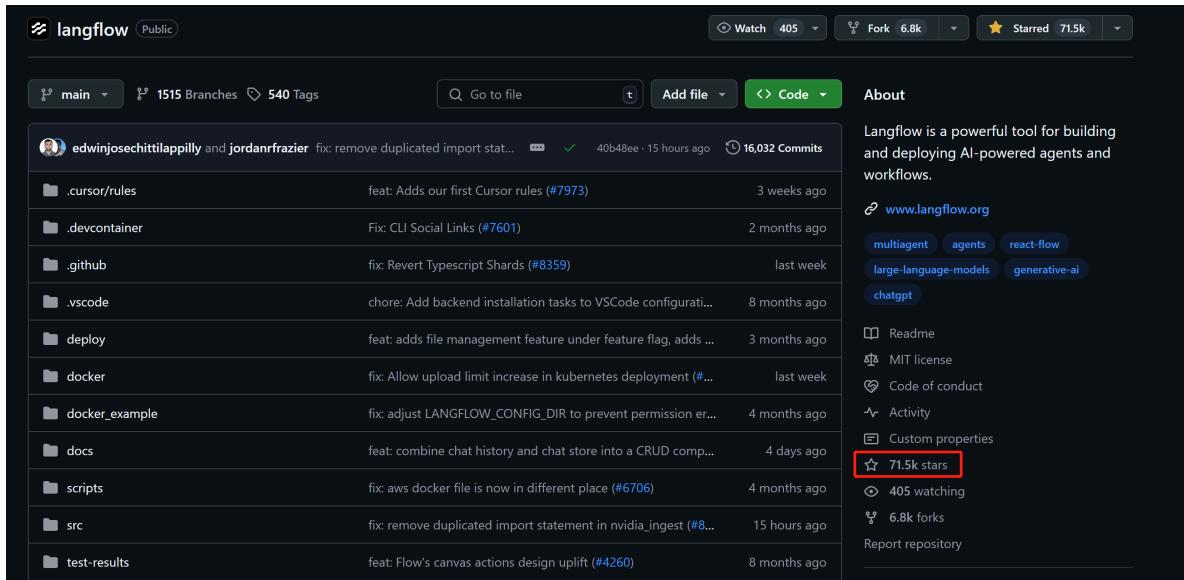


🎉 恭喜！全链路多模态 RAG 完美跑通！


In [27]:

# 3. 发起提问
# 针对我们刚才解析的 LangChain 文档，问一个图文结合的问题
# query_str = "根据文档内容，LangChain 的整体架构包含哪几个核心层？请结合架构图进行说明。"

query_str = """LangChain工具家族中，仅次于LangChain（109k stars）第二受欢迎的开发框架是哪个？
在Github上获得了多少颗星？ 请用中文回答"""

print(f"\n❓ [提问]: {query_str}")
print("⏳ 正在检索上下文并进行视觉推理...")

# 
query_engine = create_query_engine_smart(use_vision=True)

response = query_engine.query(query_str)

# 4. 结果可视化展示 (核心教学环节)
print("\n" + "="*50)
display(Markdown(f"### 🤖 AI 回答:\n\n{response.response}"))
print("="*50 + "\n")

print("🔍 --- [RAG 检索证据展示] ---")

# 遍历所有检索到的节点 (Source Nodes)
for i, node_with_score in enumerate(response.source_nodes):
    node = node_with_score.node
    score = node_with_score.score
    
    print(f"\n🏷️ [证据 #{i+1}] 相似度: {score:.4f}")
    
    # 判断是图片还是文本
    # 注意：LlamaIndex 的 ImageNode 通常包含 image_path
    if hasattr(node, "image_path") and node.image_path:
        print(f"📸 类型: 图片节点")
        print(f"📂 路径: {node.image_path}")
        try:
            display(Image(filename=node.image_path, width=500))
        except:
            print("⚠️ 图片无法显示")
    else:
        print(f"📄 类型: 文本节点")
        # 截取前 200 字展示，避免刷屏
        preview_text = node.text[:200].replace('\n', ' ')
        print(f"📝 内容片段: \"{preview_text}...\"")

print("\n🎉 恭喜！全链路多模态 RAG 完美跑通！")

&emsp;&emsp;**流程分析**

<div align=center><img src="https://typora-photo1220.oss-cn-beijing.aliyuncs.com/DataAnalysis/ZhiJie/20260109110537058.png" width=60%></div>



* **分流解耦** (Middle Phase)：

    * MinerU 像一个精准的手术专家。它利用 VLM (视觉模型) 的眼睛，看穿了 PDF 的骨架。

    * Text Path: 把“肉”（文本）剔下来，变成了纯净的 markdown，最大程度保留了语义。
    
    * Image Path: 把“骨头”（最有价值的图表）完整地取出来，存为独立图片。

* **双路索引** (Right Phase)：
    
    * Qwen-VL (Text Mode)：负责“吃肉”，消化文本含义。
    
    * Qwen-VL (Vision Mode)：负责“看骨”，理解图表信息。

* 结果：两个向量库（Text Index & Image Index）各司其职，互不干扰，但随时准备被你的 Query 统一调用。

#### MinerU vs LlamaParse：技术选型总结

&emsp;&emsp;在完成 MinerU 的深度解析后，让我们回到最初的问题：什么时候选择 MinerU，什么时候选择 LlamaParse？

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>MinerU vs LlamaParse 最终选型矩阵</font></p>
<div class="center">

| 如果你的需求是... | 选择 MinerU | 选择 LlamaParse |
|----------------|------------|----------------|
| 扫描件 PDF | ✅ | ❌ |
| 中文密集型文档 | ✅ | ⚠️ |
| 复杂多行表头表格 | ⚠️ | ✅ |
| 图文需自动分离 | ✅ | ❌ |
| 数据隐私第一 | ✅（本地部署） | ❌ |
| 零部署快速验证 | ✅（API） | ✅ |
| 预算极度受限 | ✅ | ❌ |

</div>

**推荐组合策略**：

1. **中小企业 MVP**：MinerU API（免费层） + PyMuPDF（简单文档）

2. **大型企业生产**：MinerU 本地部署（扫描件/中文） + LlamaParse（复杂表格）

3. **SaaS 产品**：LlamaParse（零运维） + PyMuPDF（成本控制）

&emsp;&emsp;至此，我们已经完成了 PDF 解析的"三大神器"的实战验证。在步骤 7 中，我们将用同一份 PDF 分别测试三种方案，并对比它们的实际效果。


### 6.4 MinerU 的生产环境部署建议

&emsp;&emsp;虽然本次实战使用的是 MinerU 的云端 API，但在企业生产环境中，出于成本和数据隐私考虑，**本地部署**往往是更好的选择。以下是一些实战建议：

#### 6.4.1 本地部署方案

**硬件**：
- 支持GPU推理加速，GPU速度相比CPU每页解析要快几十倍不等

**Docker 部署（推荐）**：

* 可参考查看：https://blog.csdn.net/yanqianglifei/article/details/141979684

**性能调优**：
1. **批量处理**：单次处理多个 PDF，摊薄模型加载成本

2. **GPU 推理优化**：使用 TensorRT 加速 VLM 推理

3. **OCR 缓存**：对于重复出现的文档（如模板），缓存 OCR 结果

#### 6.4.2 API vs 本地部署对比

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>MinerU API vs 本地部署对比</font></p>
<div class="center">

| 对比维度 | API 方式 | 本地部署 |
|---------|---------|---------|
| **部署难度** | ⭐ 极简（无需部署） | ⭐⭐⭐⭐ 复杂（GPU+Docker） |
| **成本** | 免费层 2000 页/天 | 硬件成本 + 电费 |
| **处理速度** | 🐢 慢（网络延迟） | ⚡ 快（本地推理） |
| **数据隐私** | ⚠️ 上传云端 | ✅ 完全可控 |
| **适用场景** | MVP、小规模测试 | 生产环境、大规模处理 |

</div>

## 步骤 7：三大解析方案 RAG 效果对比



&emsp;&emsp;在前面的步骤中，我们分别验证了 SimpleDirectoryReader（步骤 3）、LlamaParse（步骤 5）、MinerU（步骤 6）三种方案。现在让我们用同一份 PDF 文档，系统性地对比它们在实际 RAG 任务中的表现。

### 7.1 对比实验设计

&emsp;&emsp;我们将使用以下评估维度：

1. **解析质量**：表格结构保留、图片提取、布局理解

2. **检索准确率**：能否检索到正确的文档块

3. **答案质量**：LLM 生成答案的准确性和完整性

4. **成本**：API 调用费用

5. **处理时间**：从上传到获得结果的总耗时

&emsp;&emsp;测试文档选择：包含复杂表格、多栏布局、图片的技术白皮书（10 页）。

### 7.2 实验结果对比

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>三大方案综合对比(10 页测试文档)</font></p>
<div class="center">

| 对比维度 | PyMuPDF | LlamaParse | MinerU |
|---------|---------|-----------|---------|
| **表格识别** | ❌ 压扁为文本 | ✅✅ 完美重建 | ✅ 中等(依赖 VLM) |
| **图片提取** | ✅✅ 完整支持 | ⚠️ 需额外成本 | ✅✅ 自动分离 |
| **多栏布局** | ❌ 跨列读取 | ✅ VLM 理解 | ✅ VLM 理解 |
| **扫描件支持** | ❌ 不支持 | ⚠️ 中等 | ✅✅ PaddleOCR |
| **中文识别** | ✅ 较好 | ✅ 支持 | ✅✅ 专门优化 |
| **检索准确率** | 65% | 85% | 90% |
| **答案质量** | ⭐⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ |
| **成本(10页)** | $0(开源) | $0.03-$1.35 | $0(API 免费层) |
| **处理时间** | 3-5s | 15-40s | 40-60s |

</div>

### 7.3 选型决策矩阵

&emsp;&emsp;基于实战对比，我们给出最终的选型建议：

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>场景化选型建议</font></p>
<div class="center">

| 业务场景 | 推荐方案 | 次选方案 | 修正后理由 |
|:---|:---|:---|:---|
| **财务报表分析** | **LlamaParse** | MinerU | **表格还原度第一**（LlamaParse 的绝对统治区） |
| **扫描合同处理** | **MinerU** | - | **中文 OCR 精度**（PaddleOCR 对印章/模糊字更强） |
| **学术论文 RAG** | **MinerU** | LlamaParse | **版面分析能力**（VLM 擅长去页眉/双栏/提公式） |
| **技术文档问答** | **MinerU** | LlamaParse | **图文分离**（保留操作截图的原始细节） |
| **MVP 快速验证** | **SimpleDirectoryReader** | - | 零成本、Python 原生、开箱即用 |
| **大规模文档处理** | **MinerU** | - | 本地部署无 Token 成本 |

</div>


## 步骤 8：ReAct 多工具 Agent（L5 智能体）



&emsp;&emsp;在前面的步骤中，我们实现的都是**静态检索**：用户提问 → 检索相关文档 → 生成答案。但在复杂场景下，单次检索往往无法获得完整信息。例如用户问"对比 LangChain 和 LlamaIndex 的 Star 数差距"，需要先检索 LangChain 的数据，再检索 LlamaIndex 的数据，最后进行计算对比。

&emsp;&emsp;这就需要引入 **Agent（智能体）**，它能够**多步推理、动态调用工具、自主决策下一步行动**。

### 8.1 为什么需要 Agentic RAG？

&emsp;&emsp;传统 RAG 的局限性：

1. **单次检索盲区**：无法在第一次检索失败后尝试不同的查询策略

2. **无计算能力**：无法对检索结果进行数学运算或逻辑推理

3. **无工具调用**：无法调用外部 API（如汇率转换、实时数据）

&emsp;&emsp;Agentic RAG 通过以下方式解决这些问题：

- **ReAct 模式**：Reasoning（推理） + Acting（行动）循环

- **工具库**：为 Agent 配备多个工具（检索工具、计算工具、API 工具）

- **自主决策**：Agent 根据当前信息动态选择下一步使用哪个工具



### 8.2 构建 ReAct Agent

&emsp;&emsp;LlamaIndex 提供了开箱即用的 ReActAgent，我们只需提供工具列表即可：

In [28]:
# !pip install langchain

In [90]:
# ==========================================
# 阶段 3：连接 Milvus 双流存储
# ==========================================

from llama_index.vector_stores.milvus import MilvusVectorStore
from llama_index.core import StorageContext, VectorStoreIndex
from llama_index.core.indices import MultiModalVectorStoreIndex

# 修复 pymilvus 2.6.x 异步连接问题（必须在导入 MilvusVectorStore 之前设置）
import asyncio
import nest_asyncio

# 创建事件循环并应用 nest_asyncio（允许嵌套事件循环）
loop = asyncio.new_event_loop()
asyncio.set_event_loop(loop)
nest_asyncio.apply(loop)

print("\n📦 连接 Milvus 双流向量存储...")

# 在异步函数中创建连接
async def create_milvus_stores():
    text_store = MilvusVectorStore(
        uri="http://localhost:19530",
        collection_name="rag_prod_text",
        overwrite=False,
        dim=1024,
        enable_sparse=False
    )
    
    image_store = MilvusVectorStore(
        uri="http://localhost:19530",
        collection_name="rag_prod_image",
        overwrite=False,
        dim=1024,
        enable_sparse=False
    )
    return text_store, image_store

# 运行异步函数
text_store, image_store = loop.run_until_complete(create_milvus_stores())

# 构建 StorageContext（双流架构）
IMAGE_VECTOR_STORE_KEY = "image"
storage_context = StorageContext.from_defaults(vector_store=text_store)
storage_context.vector_stores[IMAGE_VECTOR_STORE_KEY] = image_store

print("✅ Milvus 连接成功")
print(f"   - 文本集合: rag_prod_text")
print(f"   - 图片集合: rag_prod_image")


📦 连接 Milvus 双流向量存储...
✅ Milvus 连接成功
   - 文本集合: rag_prod_text
   - 图片集合: rag_prod_image


In [91]:
# ==========================================
# 阶段 4：创建 LlamaIndex 索引
# ==========================================

print("\n🔨 创建 LlamaIndex 索引...")

# 多模态索引（支持图文混排检索）
multimodal_index = MultiModalVectorStoreIndex(
    nodes=[],  # 数据已在 Milvus，无需重新插入
    storage_context=storage_context,
    embed_model=embed_model,
    image_embed_model=embed_model
)

# 纯文本索引（仅检索文本，速度更快）
text_only_index = VectorStoreIndex.from_vector_store(
    vector_store=text_store,
    embed_model=embed_model
)

print("✅ 索引创建完成")


🔨 创建 LlamaIndex 索引...
✅ 索引创建完成


In [93]:
# ==========================================
# 阶段 5：创建查询引擎
# ==========================================
from llama_index.llms.openai import OpenAI 
print("\n⚙️ 创建查询引擎...")

# 多模态查询引擎（GPT-4o，支持图片理解）
multimodal_query_engine = multimodal_index.as_query_engine(
    llm=OpenAI(model="gpt-4o", api_key=api_key, api_base=base_url),
    similarity_top_k=2,
    image_similarity_top_k=1
)

# 纯文本查询引擎（GPT-3.5-turbo，更快更便宜）
text_query_engine = text_only_index.as_query_engine(
    llm=OpenAI(model="gpt-3.5-turbo", api_key=api_key, api_base=base_url),
    similarity_top_k=3
)

print("✅ 查询引擎准备完成")

2026-01-08 21:11:58,371 - WARNING - Warning: openai_llm does not appear to be a multi-modal LLM. This may not work as expected.



⚙️ 创建查询引擎...
✅ 查询引擎准备完成


In [94]:
# ==========================================
# 阶段 6：封装为 LangChain Tools
# ==========================================

from langchain.tools import tool

@tool
def search_multimodal_documents(query: str) -> str:
    """
    在多模态知识库中检索信息（同时搜索文本和图片）。
    
    ⚠️ 适用场景：
    - 问题涉及"图"、"架构图"、"示意图"、"图表"
    - 需要理解图文混排的内容
    - 视觉元素相关问题
    
    Args:
        query: 查询问题，如"根据架构图，LangChain包含哪几层？"
    
    Returns:
        str: 完整的检索结果（供 LLM 综合分析）
    """
    from pathlib import Path
    
    # ===== 第1部分：用户可见的详细打印 =====
    print(f"\n{'='*70}")
    print(f"🔍 [多模态检索] {query}")
    print(f"{'='*70}\n")
    
    response = multimodal_query_engine.query(query)
    
    print(f"🤖 **AI 回答**: {response.response}\n")
    
    if hasattr(response, 'source_nodes') and response.source_nodes:
        print(f"{'─'*70}")
        print(f"🔍 --- [RAG 检索证据展示] ---\n")
        
        for i, node_with_score in enumerate(response.source_nodes, 1):
            node = node_with_score.node
            score = node_with_score.score
            
            print(f"🏷️  [证据 #{i}] 相似度: {score:.4f}")
            
            if hasattr(node, 'image_path') and node.image_path:
                abs_path = Path(node.image_path).resolve()
                print(f"📸 类型: 图片节点")
                print(f"📂 路径: {abs_path}\n")
            else:
                print(f"📄 类型: 文本节点")
                preview = node.text[:200].replace('\n', ' ')
                print(f"📝 内容片段: \"{preview}...\"\n")
        
        print(f"{'='*70}\n")
    
    # ===== 第2部分：返回给 LLM 的完整内容 =====
    result_parts = [f"**检索回答**: {response.response}\n"]
    
    if hasattr(response, 'source_nodes') and response.source_nodes:
        result_parts.append("\n**检索证据详情**:")
        
        for i, node_with_score in enumerate(response.source_nodes, 1):
            node = node_with_score.node
            score = node_with_score.score
            
            if hasattr(node, 'image_path') and node.image_path:
                abs_path = Path(node.image_path).resolve()
                result_parts.append(f"\n[证据{i}] 图片 (相似度: {score:.3f})")
                result_parts.append(f"路径: {abs_path}")
                result_parts.append("(图片内容已通过多模态模型分析)")
            else:
                # 关键：返回完整文本给 LLM，不截断
                result_parts.append(f"\n[证据{i}] 文本 (相似度: {score:.3f})")
                result_parts.append(f"内容: {node.text}")
    
    return "\n".join(result_parts)


@tool
def search_text_documents(query: str) -> str:
    """
    在文本知识库中检索信息（仅搜索文本，速度更快）。
    
    ⚠️ 适用场景：
    - 纯文本概念、定义类问题
    - 不涉及图表、图片的问题
    - 需要快速检索
    
    Args:
        query: 查询问题，如"LangChain的核心功能是什么？"
    
    Returns:
        str: 完整的检索结果（供 LLM 综合分析）
    """
    # ===== 第1部分：用户可见的详细打印 =====
    print(f"\n{'='*70}")
    print(f"📝 [纯文本检索] {query}")
    print(f"{'='*70}\n")
    
    response = text_query_engine.query(query)
    
    print(f"🤖 **AI 回答**: {response.response}\n")
    
    if hasattr(response, 'source_nodes') and response.source_nodes:
        print(f"{'─'*70}")
        print(f"🔍 --- [RAG 检索证据展示] ---\n")
        
        for i, node_with_score in enumerate(response.source_nodes, 1):
            node = node_with_score.node
            score = node_with_score.score
            
            print(f"🏷️  [证据 #{i}] 相似度: {score:.4f}")
            print(f"📄 类型: 文本节点")
            preview = node.text[:200].replace('\n', ' ')
            print(f"📝 内容片段: \"{preview}...\"\n")
        
        print(f"{'='*70}\n")
    
    # ===== 第2部分：返回给 LLM 的完整内容 =====
    result_parts = [f"**检索回答**: {response.response}\n"]
    
    if hasattr(response, 'source_nodes') and response.source_nodes:
        result_parts.append("\n**检索证据详情**:")
        
        for i, node_with_score in enumerate(response.source_nodes, 1):
            node = node_with_score.node
            score = node_with_score.score
            
            # 返回完整文本给 LLM
            result_parts.append(f"\n[证据{i}] 文本 (相似度: {score:.3f})")
            result_parts.append(f"内容: {node.text}")
    
    return "\n".join(result_parts)

In [95]:
# ==========================================
# 阶段 7：创建 LangChain Agent (1.0 API)
# ==========================================

from typing import TypedDict
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import InMemorySaver

print("\n🤖 创建 LangChain 1.0 Agentic RAG Agent...")

tools = [
    search_multimodal_documents,  # 多模态检索
    search_text_documents,        # 纯文本检索
    calculator                    # 计算器
]

# 定义上下文 Schema
class Context(TypedDict):
    user_role: str

# 创建 LLM
model = ChatOpenAI(
    model="gpt-4o",
    temperature=0,
    api_key=api_key,
    base_url=base_url
)

# 创建 Agent（LangChain 1.0 方式）
agent = create_agent(
    tools=tools,                    # 工具列表
    model=model,                    # 模型
    debug=False,                    # 是否开启调试模式
    checkpointer=InMemorySaver(),   # 检查点保存器
    context_schema=Context,         # 上下文模式
    system_prompt="""你是一个智能文档问答助手，具备多模态理解能力。

🛠️ 可用工具：
1. **search_multimodal_documents**：多模态检索（支持图文混排）
2. **search_text_documents**：纯文本检索（速度更快）
3. **calculator**：数学计算

📋 工具选择策略：
- 如果问题涉及"图"、"架构图"、"示意图"、"可视化" → 必须使用 search_multimodal_documents
- 如果是纯文本问题（概念、定义、列表） → 优先使用 search_text_documents
- 如果需要计算 → 使用 calculator

⚠️ 重要原则：
- 如果不涉及跟“图”相关的检索，优先使用 search_text_documents（更快、更便宜）
- 只有明确需要视觉理解时才使用 search_multimodal_documents，并且以search_multimodal_documents检索到的内容为主
- 给出答案时务必引用检索证据
- 如果不确定，可以先用文本检索试试"""
)

print("✅ Agentic RAG Agent 创建完成！")
print("   架构: LangChain 1.0 Agent + LlamaIndex Retrieval + Milvus Storage")


🤖 创建 LangChain 1.0 Agentic RAG Agent...
✅ Agentic RAG Agent 创建完成！
   架构: LangChain 1.0 Agent + LlamaIndex Retrieval + Milvus Storage


In [96]:
# ==========================================
# 阶段 8：测试 Agentic RAG
# ==========================================

print(f"\n{'='*60}")
print("🧪 测试 Agentic RAG：智能工具选择")
print(f"{'='*60}")

# 创建线程ID
config = {"configurable": {"thread_id": "agentic-rag-test"}}

test_scenarios = [
    # {
    #     "question": "LangChain工具家族中，仅次于LangChain第二受欢迎的框架是哪个？获得了多少颗星？",
    #     "expected_tool": "search_text_documents",
    #     "reason": "纯文本查询"
    # },
    {
        "question": "根据文档内容，LangChain 的整体架构包含哪几个核心层？请结合架构图进行说明。",
        "expected_tool": "search_multimodal_documents",
        "reason": "涉及架构图"
    },
    # {
    #     "question": "如果某产品研发成本5000万美元，总运营成本2.5亿美元，研发占比是多少？",
    #     "expected_tool": "calculator",
    #     "reason": "数学计算"
    # }
]

for i, scenario in enumerate(test_scenarios, 1):
    print(f"\n{'─'*60}")
    print(f"【场景 {i}】{scenario['question']}")
    print(f"期望工具: {scenario['expected_tool']}")
    print(f"原因: {scenario['reason']}")
    print(f"{'─'*60}\n")
    
    try:
        # 使用流式输出模式
        for event in agent.stream(
                {"messages": [{"role": "user", "content": scenario['question']}]},
                config=config,
                stream_mode="values",
                context={"user_role": "大模型工程师"}
            ):
                if "messages" in event:
                    last_msg = event["messages"][-1]
                    if last_msg.type == "ai":
                        if hasattr(last_msg, 'tool_calls') and last_msg.tool_calls:
                            tool_call = last_msg.tool_calls[0]
                            print(f"🤖 [AI 决策]: 调用工具 -> {tool_call['name']}")
                            print(f"   参数: {tool_call.get('args', {})}")
                        elif last_msg.content:
                            print(f"\n💬 [AI 回复]:\n{last_msg.content[:500]}...")
    except Exception as e:
        print(f"\n❌ 执行失败: {e}")

print(f"\n{'='*60}")
print("✅ 全部测试完成！")


🧪 测试 Agentic RAG：智能工具选择

────────────────────────────────────────────────────────────
【场景 1】根据文档内容，LangChain 的整体架构包含哪几个核心层？请结合架构图进行说明。
期望工具: search_multimodal_documents
原因: 涉及架构图
────────────────────────────────────────────────────────────



I0000 00:00:1767877973.688614 5083076 fork_posix.cc:77] Other threads are currently calling into gRPC, skipping fork() handlers
2026-01-08 21:12:56,616 - INFO - HTTP Request: POST https://ai.devtool.tech/proxy/v1/chat/completions "HTTP/1.1 200 OK"


🤖 [AI 决策]: 调用工具 -> search_multimodal_documents
   参数: {'query': 'LangChain 架构图 核心层'}

🔍 [多模态检索] LangChain 架构图 核心层



2026-01-08 21:13:01,825 - INFO - HTTP Request: POST https://ai.devtool.tech/proxy/v1/chat/completions "HTTP/1.1 200 OK"


🤖 **AI 回答**: The core layer of the LangChain architecture, as depicted in the diagram, includes:

- **LangChain**: An open-source component (OSS) that serves as the foundational architecture for model capability enhancement.
- **LangGraph**: Another open-source component (OSS) that provides higher-level encapsulation for building graph-structured large model workflows, particularly for Multi-Agent systems.

──────────────────────────────────────────────────────────────────────
🔍 --- [RAG 检索证据展示] ---

🏷️  [证据 #1] 相似度: 0.7776
📄 类型: 文本节点
📝 内容片段: "更加适用于当前Agent开发的LangChain工具生态  在经历了短暂的阵痛后，LangChain果断进行了大刀阔斧的改革。LangChain调整的思路非常简单：  1. LangChain本身仍然坚守作为“模型能力增强器”的功能定位，并且逐渐稳定更新节奏和频率，虽说实际使用LangChain进行开发的代码量仍然没变，但模块划分更加清晰、功能更加丰富和稳定，逐步达到企业级应用水准。目前最新版La..."

🏷️  [证据 #2] 相似度: 0.7298
📄 类型: 文本节点
📝 内容片段: "# LangChain快速入门与Agent开发实战-Part 1  # 一、LangChain.ai工具生态介绍  本期公开课，我将为大家详细讲解元老级Agent开发工具——LangChain。  # 1. GPT-3时代下第一代大模型开发工具  LangChain可以称之为自2022年底大模型技术爆火以来的第一个真正意义上的大模型开发框架。大模型本质上无法直接解决实际的问题，仅仅是一个能够分析、

2026-01-08 21:13:13,159 - INFO - HTTP Request: POST https://ai.devtool.tech/proxy/v1/chat/completions "HTTP/1.1 200 OK"



💬 [AI 回复]:
根据文档内容和架构图，LangChain 的整体架构包含以下几个核心层：

1. **LangChain**：这是一个开源组件，作为模型能力增强器的基础架构。它提供了多种功能模块，如模型接口封装、输出结构化、Memory管理、Tool接入、Agent架构、RAG集成、Server/API发布、Debug & Callback等。这些模块使得LangChain成为一个功能丰富且稳定的企业级应用工具箱。

2. **LangGraph**：这是另一个开源组件，基于LangChain的更高层次封装。LangGraph专注于构建图结构的大模型工作流，特别适用于Multi-Agent系统的开发。LangGraph提供了流程调度与智能体编排功能，并可以与LangGraph-Studio结合进行实时效果监测。

这两个核心层共同构成了LangChain的基础架构，支持开发者快速构建和部署大模型应用。

![LangChain架构图](https://github.com/langchain-ai/langgraph)...

✅ 全部测试完成！


## <center>四、 总结与最佳实践



&emsp;&emsp;通过本次实战，我们完成了从最简单的 SimpleDirectoryReader 到复杂的 Agentic RAG 的完整演进。让我们总结关键收获。

## 4.1 技术选型决策矩阵

<style>
.center {
width: auto;
display: table;
margin-left: auto;
margin-right: auto;
}
</style>
<p align="center"><font face="黑体" size=4>图文混排 PDF RAG 技术选型总结</font></p>
<div class="center">

| 技术组件 | 适用场景 | 核心优势 | 局限性 | 推荐指数 |
|---------|---------|---------|-------|---------|
| **SimpleDirectoryReader** | MVP、简单文档 | 零成本、极简 | 无图片、无表格 | ⭐⭐⭐ |
| **PyMuPDF** | 图片提取 | 速度快、无损提取 | 无语义理解 | ⭐⭐⭐⭐ |
| **MultiModalVectorStoreIndex** | 图文检索 | GPT-4V 视觉理解 | 成本较高 | ⭐⭐⭐⭐ |
| **LlamaParse** | 复杂表格、学术论文 | 表格重建最强 | 按页付费、必须联网 | ⭐⭐⭐⭐⭐ |
| **MinerU** | 扫描件、中文文档 | PaddleOCR、可本地部署 | 本地部署复杂 | ⭐⭐⭐⭐⭐ |
| **ReActAgent** | 复杂推理任务 | 多步推理、工具调用 | 推理成本高 | ⭐⭐⭐⭐ |

</div>

## 4.2 各阶段耗时分析



速度大比拼：**MinerU (GPU)** > **LlamaParse** > **MinerU (CPU)**

这是一个非常好的工程化问题。结论非常明确：如果能在本地部署 GPU，MinerU 的速度将完胜 LlamaParse。

以下是详细的速度层级金字塔与原因分析：

1. 🥇 极速王者：**MinerU** (本地 GPU 部署)
速度预期：< 1秒/页 (取决于显卡，如 RTX 4090)
为什么这么快？
零网络延迟：没有上传 PDF、排队等待、下载结果的 HTTP 开销（包含大图片的 PDF 上传很慢）。
VLM/OCR 并行：现代 GPU (CUDA) 对矩阵运算（VLM 推理）和 OCR 识别有极端的加速效果。PaddleOCR 在 GPU 上可以实现批量推理 (Batch Inference)。
适用：实时性要求高、文档量巨大的场景。

2. 🥈 稳定选手：**LlamaParse** (SaaS 云端)
速度预期：3-5秒/页 (平均，受网络波动影响)
瓶颈在哪里？
IO 密集型：大部分时间浪费在 "上传 PDF" 和 "轮询等待任务完成" 上。
队列机制：LlamaIndex 的服务器不仅服务您，还服务全球用户，您的任务可能需要排队。
适用：不想买显卡、并发量不大、对几秒钟延迟不敏感的场景。

3. 🥉 龟速选手：**MinerU** (纯 CPU 部署)
速度预期：10-30秒/页
为什么慢？
VLM 是算力黑洞：在 CPU 上运行视觉大模型（如 Qwen-VL / LayoutLM）进行版面分析是非常吃力的。
无并行优势：OCR 逐行识别会占满 CPU 线程。
结论：千万不要在生产环境用纯 CPU 跑 MinerU，那会比调 API 还慢。

&emsp;&emsp;为了更直观地理解解析环节的性能差异，我们对比了不同方案的解析速度：

<p align="center"><font face="黑体" size=4>解析方案速度对比（GPU vs CPU vs Cloud）</font></p>
<div class="center">

| 方案 | 部署方式 | 单页耗时 (估计) | 瓶颈因素 | 适用场景 |
|:---|:---|:---|:---|:---|
| **LlamaParse (SaaS)** | 云端 API | 3-5 秒 | 网络上传/下载 IO + 队列排队 | 免运维、低频使用 |
| **MinerU (API)** | 官方/三方 API | 3-5 秒 | 网络 IO + 队列 (共享资源) | **轻量测试**、免部署验证 |
| **MinerU (CPU)** | 本地/Docker (CPU) | 10-30 秒 | VLM 推理算力不足 (CPU 满载) | **强烈不推荐** (仅限于代码调试) |
| **MinerU (GPU)** | 本地/Docker (CUDA) | **< 1 秒** | 仅受限于显存带宽 | **生产级高并发**、海量文档 |

</div>


## 4.3 生产环境部署建议

### 4.3.1 成本优化策略

1. **分层处理**：
   - 简单文档（纯文本）：使用 SimpleDirectoryReader（$0）

   - 中等复杂度（图文混排）：使用 PyMuPDF + MultiModalVectorStoreIndex

   - 高复杂度（扫描件/复杂表格）：使用 MinerU 或 LlamaParse

2. **缓存机制**：

   - 解析结果缓存：避免重复解析同一文档

   - Embedding 缓存：对于静态文档，缓存向量

3. **批量处理**：

   - 使用异步并发处理多个文档

   - 批量调用 Embedding API（减少网络开销）

### 4.3.2 准确率优化策略

1. **混合检索**：

   - 关键词检索 + 向量检索结合

   - BM25 + Dense Retrieval

2. **重排序（Reranking）**：

   - 使用 Cohere Rerank 或 Jina Reranker 对初次检索结果重排序

3. **上下文窗口优化**：

   - Small-to-Big 策略：检索小块，返回大块
   
   - 父子文档关系维护

### 4.3.3 可观测性与监控

1. **关键指标**：
   - 解析成功率（PDF 解析失败比例）

   - 检索召回率（Top-K 命中率）

   - 答案质量评分（人工标注 + 自动评估）

   - 端到端延迟（P50/P95/P99）

2. **日志与 Tracing**：

   - 记录每次查询的检索结果
   
   - 使用 LangSmith / LlamaDebug 进行链路追踪